In [1]:
%load_ext autoreload
%autoreload 2

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["figure.facecolor"] = 'white'
matplotlib.rcParams["axes.facecolor"] = 'white'
matplotlib.rcParams["savefig.facecolor"] = 'white'
matplotlib.rcParams["text.color"] = 'black'
matplotlib.rcParams["axes.labelcolor"] = 'black'
matplotlib.rcParams["xtick.color"] = 'black'
matplotlib.rcParams["ytick.color"] = 'black'
matplotlib.rcParams["axes.edgecolor"] = 'black'
matplotlib.rcParams["axes.spines.right"] = False
matplotlib.rcParams["axes.spines.top"] = False
matplotlib.rcParams['font.family'] = 'cmss10'
matplotlib.rcParams['axes.formatter.use_mathtext'] = True
matplotlib.rcParams['mathtext.fontset'] = 'cm'

tick_fontsize = 18
label_fontsize = 20
title_fontsize = 28
legend_fontsize = 18
letter_fontsize = 21


cat_cmap = plt.get_cmap('Dark2')
cat_cmap_2 = plt.get_cmap('Pastel1')
cat_cmap_3 = plt.get_cmap('Accent')

sd_col = plt.get_cmap('Set2')(4)
hd_col = plt.get_cmap('Set2')(3)
ad_col = plt.get_cmap('Set2')(2)
av_col = plt.get_cmap('Set2')(1)
pos_col = plt.get_cmap('Set2')(0)

hd_cmap = plt.get_cmap('managua')
sd_cmap = plt.get_cmap('vanimo')

import o2s
import o2s.Tasks as Tasks

import gc
import sys
import numpy as np


/Users/jakelaherty/miniforge3/envs/O2S/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jakelaherty/miniforge3/envs/O2S/lib/python3.12/site-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403213615/work/aten/src/ATen/native/TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [ ]:
task = o2s.task.Task.named('HD_SD-0D')
o2s.build.build(task, use_wandb=True)

wandb: Currently logged in as: jakelaherty (jakelaherty-gatsby-computational-neuroscience-unit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


In [7]:

from o2s.Tasks import SD_0D
checkpoint_path = '../trained-models/1741628198.4426634-task:SD-0D/checkpoint-epochs:2100/net.pt'

checkpoint = torch.load(checkpoint_path, map_location=device)
task = Task.from_checkpoint(checkpoint)
task.config.update(device=device, tau=1, dt=0.1)
torch.set_default_dtype(torch.float64 if task.config.precise else torch.float32)
net = RNN(task)
net.load_state_dict(checkpoint['net_state_dict'])
net.state_noise_std = 0

In [8]:
test = task.copy(av_step_zero_prob=0)
test_batch = TaskDataset(test).get_batch()
with torch.no_grad():
    sd_0d_test_sd_target = test_batch['vars']['sd'][0,:].cpu().numpy()
    sd_0d_test_states, _, sd_0d_test_outputs = net(test_batch['inputs'], noise=test_batch['noise'])
    sd_0d_test_states, sd_0d_test_outputs = sd_0d_test_states.cpu(), sd_0d_test_outputs.cpu()
    sd_0d_test_sd_pred = torch.atan2(sd_0d_test_outputs[0, :, 0], sd_0d_test_outputs[0, :, 1]).numpy()
    sd_0d_test_sd_pred[sd_0d_test_sd_pred < 0] += 2 * np.pi
del test, test_batch, sd_0d_test_outputs

T = np.linspace(0, task.config.n_timesteps/10, task.config.n_timesteps)
dt = T[1] - T[0]
sd_0d_test_sd_pred_x = []
sd_0d_test_sd_pred_y = []
for i, (t, sd) in enumerate(zip(T, sd_0d_test_sd_pred)):
    if i == 0:
        sd_0d_test_sd_pred_x.append(t)
        sd_0d_test_sd_pred_y.append(sd)
    else:
        diff = sd - sd_0d_test_sd_pred_y[-1]
        if np.abs(diff) > np.pi:
            sd_0d_test_sd_pred_x.extend([t - dt/2, t])
            sd_0d_test_sd_pred_y.extend([np.nan, sd])
        else:
            sd_0d_test_sd_pred_x.append(t)
            sd_0d_test_sd_pred_y.append(sd)

sd_0d_test_sd_target_x = []
sd_0d_test_sd_target_y = []
for i, (t, sd) in enumerate(zip(T, sd_0d_test_sd_target)):
    if i == 0:
        sd_0d_test_sd_target_x.append(t)
        sd_0d_test_sd_target_y.append(sd)
    else:
        diff = sd - sd_0d_test_sd_target_y[-1]
        if np.abs(diff) > np.pi:
            sd_0d_test_sd_target_x.extend([t - dt/2, t])
            sd_0d_test_sd_target_y.extend([np.nan, sd])
        else:
            sd_0d_test_sd_target_x.append(t)
            sd_0d_test_sd_target_y.append(sd)

In [ ]:
tuning_batch_size = 5000
tuning_vars_list = ['HD', 'ego_SD', 'allo_SD', 'AV']
n_diff_bins = 50
sd_0d_example_neurons = [0, 7]

(array([48., 32., 23., 17., 17., 17., 13., 19.,  7.,  5., 15.,  9., 11.,
         9., 10.,  7., 10.,  8.,  7., 10.,  9.,  8.,  8.,  9.,  3.,  8.,
         5., 12.,  8.,  3.,  8.,  6., 11., 10.,  6.,  4.,  6.,  4., 10.,
         3.,  6.,  3.,  6.,  8.,  8.,  6.,  8.,  2.,  4.,  5.,  8.,  5.,
         6.,  6.,  3.,  9.,  3.,  5.,  9.,  6.,  5.,  7.,  9.,  7.,  8.,
         9., 10.,  6.,  4.,  8., 11.,  6.,  7.,  8., 11.,  6.,  5.,  7.,
         3.,  6.,  9., 13.,  9., 10., 12., 11.,  6.,  7.,  9., 11., 10.,
         8., 12., 18., 26., 17., 13., 24., 22., 59.]),
 array([-9.99900990e-01, -9.79901980e-01, -9.59902970e-01, -9.39903960e-01,
        -9.19904950e-01, -8.99905940e-01, -8.79906930e-01, -8.59907921e-01,
        -8.39908911e-01, -8.19909901e-01, -7.99910891e-01, -7.79911881e-01,
        -7.59912871e-01, -7.39913861e-01, -7.19914852e-01, -6.99915842e-01,
        -6.79916832e-01, -6.59917822e-01, -6.39918812e-01, -6.19919802e-01,
        -5.99920792e-01, -5.79921782e-01, -5.59922773e

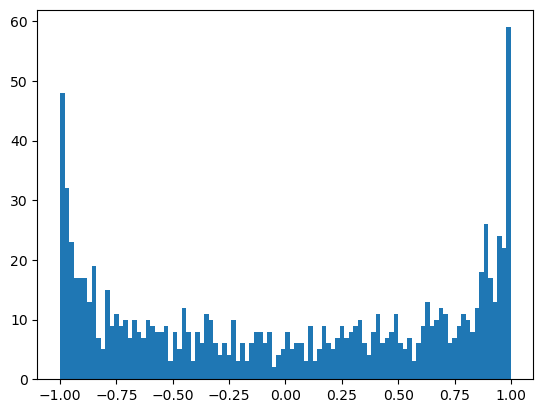

In [6]:
import numpy as np
import matplotlib.pyplot as plt

mean = 0
std = np.pi
N = 1000

x = np.random.normal(loc=mean, scale=std, size=(N,))
y = np.cos(x)

plt.hist(y, bins=100)

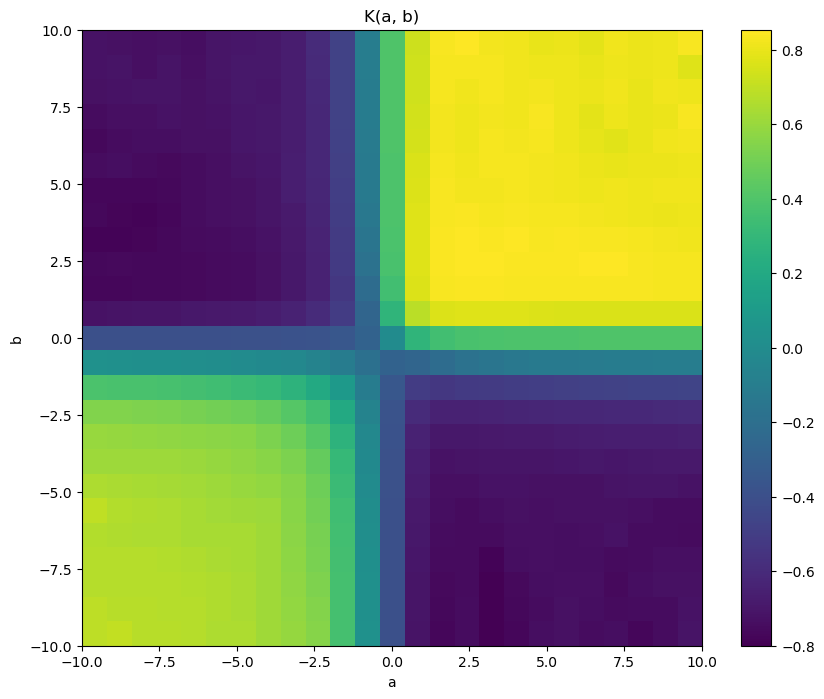

In [25]:
import numpy as np
from scipy.stats import qmc, norm
import matplotlib.pyplot as plt

phi = np.tanh

def dphi(x):
    t = np.tanh(x)
    return 1.0 - t * t


# ----------------------------
# Problem setup
# ----------------------------
sigma_m = 1
sigma_n = 1
sigma_A = 1
sigma_B = 1

rho_mn = 0.7
rho_mA = 0
rho_mB = 0
rho_nA = 0.5
rho_nB = 0.5
rho_AB = 0

cov = np.array([
    [sigma_m**2,                rho_mn*sigma_m*sigma_n,         rho_mA*sigma_m*sigma_A,         rho_mB*sigma_m*sigma_B],
    [rho_mn*sigma_m*sigma_n,    sigma_n**2,                     rho_nA*sigma_n*sigma_A,         rho_nB*sigma_n*sigma_B],
    [rho_mA*sigma_m*sigma_A,    rho_nA*sigma_n*sigma_A,         sigma_A**2,                     rho_AB*sigma_A*sigma_B],
    [rho_mB*sigma_m*sigma_B,    rho_nB*sigma_n*sigma_B,         rho_AB*sigma_A*sigma_B,         sigma_B**2]
], dtype=np.float64)

L = np.linalg.cholesky(cov)


# ----------------------------
# Precompute Sobol-Gaussian samples ONCE
# ----------------------------
def make_correlated_samples(L, n_power=14, seed=0):
    """
    Returns correlated Gaussian samples x = z @ L.T, shape (N, 4),
    where N = 2**n_power.
    """
    sampler = qmc.Sobol(d=4, scramble=True, seed=seed)
    u = sampler.random_base2(m=n_power)

    # avoid ppf(0) or ppf(1)
    eps = np.finfo(np.float64).eps
    u = np.clip(u, eps, 1.0 - eps)

    z = norm.ppf(u)          # (N, 4), iid standard normal
    x = z @ L.T              # (N, 4), correlated normal
    return x


samples = make_correlated_samples(L, n_power=14, seed=1234)

m  = samples[:, 0]   # shape (N,)
IA = samples[:, 2]   # shape (N,)
IB = samples[:, 3]   # shape (N,)


# ----------------------------
# Vectorised fixed-point solver over the whole grid
# ----------------------------
operand_range = np.linspace(-10, 10, 25)
A, B = np.meshgrid(operand_range, operand_range, indexing="xy")

ab = A * B

# constants appearing in c(a,b)
cA = L[1, 0] * L[2, 0] + L[1, 1] * L[2, 1]
cB = L[1, 0] * L[3, 0] + L[1, 1] * L[3, 1]
d0 = L[0, 0] * L[1, 0]

C = A * cA + B * cB
D = C + ab * d0   # full multiplicative prefactor in the fixed-point map

# initial guess
K = np.zeros_like(A, dtype=np.float64)

# useful broadcasted versions
m_  = m[:, None, None]
IA_ = IA[:, None, None]
IB_ = IB[:, None, None]

max_iter = 200
tol = 1e-10
damping = 0.7   # helps stability

for _ in range(max_iter):
    # shape: (N_samples, nA, nB)
    s = ab[None, :, :] * K[None, :, :] * m_ + A[None, :, :] * IA_ + B[None, :, :] * IB_

    exp_dphi = dphi(s).mean(axis=0)      # shape: (nA, nB)
    K_new = exp_dphi * D

    err = np.max(np.abs(K_new - K))
    K = damping * K_new + (1.0 - damping) * K

    if err < tol:
        break


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    K,
    origin="lower",
    extent=(operand_range[0], operand_range[-1], operand_range[0], operand_range[-1]),
    aspect="auto"
)
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("K(a, b)")
fig.colorbar(im, ax=ax)
plt.show()

In [166]:
import numpy as np
from scipy.stats import qmc, norm
import matplotlib.pyplot as plt

phi = np.tanh

def dphi(x):
    t = np.tanh(x)
    return 1.0 - t * t


# ----------------------------
# Problem setup
# ----------------------------
sigma_m = 1
sigma_n = 1
sigma_A = 1
sigma_B = 1

rho_mn = 0.7
rho_mA = 0
rho_mB = 0
rho_nA = 0.5
rho_nB = 0.5
rho_AB = 0

cov = np.array([
    [sigma_m**2,                rho_mn*sigma_m*sigma_n,         rho_mA*sigma_m*sigma_A,         rho_mB*sigma_m*sigma_B],
    [rho_mn*sigma_m*sigma_n,    sigma_n**2,                     rho_nA*sigma_n*sigma_A,         rho_nB*sigma_n*sigma_B],
    [rho_mA*sigma_m*sigma_A,    rho_nA*sigma_n*sigma_A,         sigma_A**2,                     rho_AB*sigma_A*sigma_B],
    [rho_mB*sigma_m*sigma_B,    rho_nB*sigma_n*sigma_B,         rho_AB*sigma_A*sigma_B,         sigma_B**2]
], dtype=np.float64)

L = np.linalg.cholesky(cov)


# ----------------------------
# Precompute Sobol-Gaussian samples ONCE
# ----------------------------
def make_correlated_samples(L, n_power=14, seed=0):
    """
    Returns correlated Gaussian samples x = z @ L.T, shape (N, 4),
    where N = 2**n_power.
    """
    sampler = qmc.Sobol(d=4, scramble=True, seed=seed)
    u = sampler.random_base2(m=n_power)

    # avoid ppf(0) or ppf(1)
    eps = np.finfo(np.float64).eps
    u = np.clip(u, eps, 1.0 - eps)

    z = norm.ppf(u)          # (N, 4), iid standard normal
    x = z @ L.T              # (N, 4), correlated normal
    return x


samples = make_correlated_samples(L, n_power=14, seed=1234)

m  = samples[:, 0]   # shape (N,)
IA = samples[:, 2]   # shape (N,)
IB = samples[:, 3]   # shape (N,)


# ----------------------------
# Vectorised fixed-point solver over the whole grid
# ----------------------------
operand_range = np.linspace(-10, 10, 25)
A, B = np.meshgrid(operand_range, operand_range, indexing="xy")

ab = A * B

# constants appearing in c(a,b)
cA = L[1, 0] * L[2, 0] + L[1, 1] * L[2, 1]
cB = L[1, 0] * L[3, 0] + L[1, 1] * L[3, 1]
d0 = L[0, 0] * L[1, 0]

C = A * cA + B * cB
D = C + ab * d0   # full multiplicative prefactor in the fixed-point map

# initial guess
K = np.zeros_like(A, dtype=np.float64)

# useful broadcasted versions
m_  = m[:, None, None]
IA_ = IA[:, None, None]
IB_ = IB[:, None, None]

max_iter = 200
tol = 1e-10
damping = 0.7   # helps stability

for _ in range(max_iter):
    # shape: (N_samples, nA, nB)
    s = ab[None, :, :] * K[None, :, :] * m_ + A[None, :, :] * IA_ + B[None, :, :] * IB_

    exp_dphi = dphi(s).mean(axis=0)      # shape: (nA, nB)
    K_new = exp_dphi * D

    err = np.max(np.abs(K_new - K))
    K = damping * K_new + (1.0 - damping) * K

    if err < tol:
        break


# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    K,
    origin="lower",
    extent=(operand_range[0], operand_range[-1], operand_range[0], operand_range[-1]),
    aspect="auto"
)
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("K(a, b)")
fig.colorbar(im, ax=ax)
plt.show()

KeyboardInterrupt: 

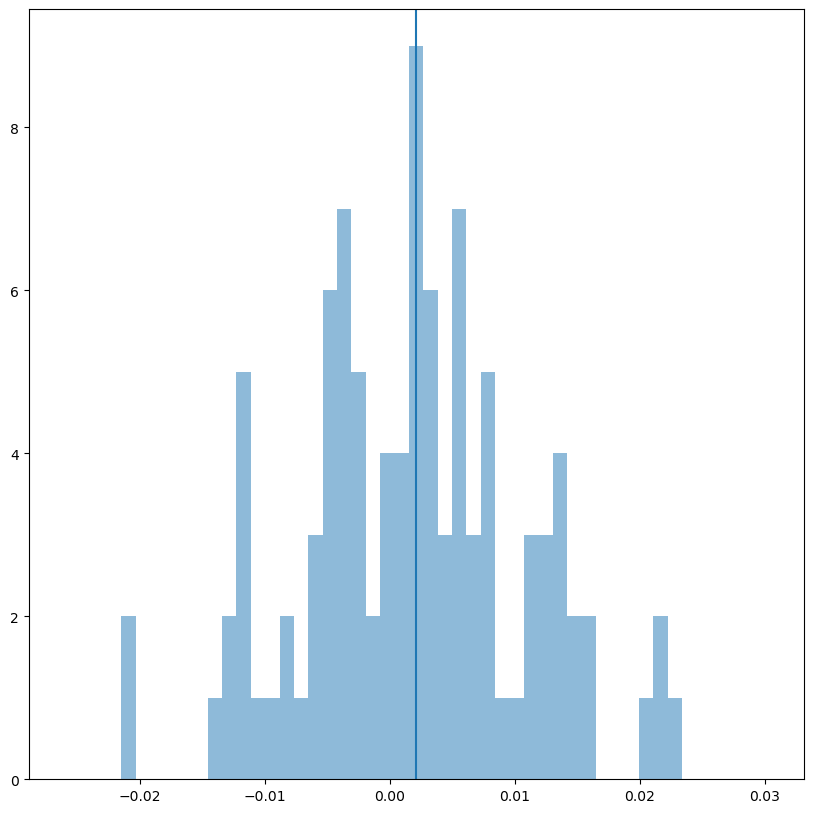

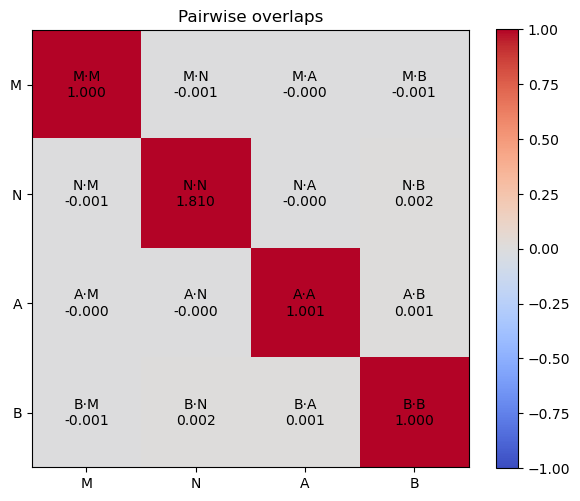

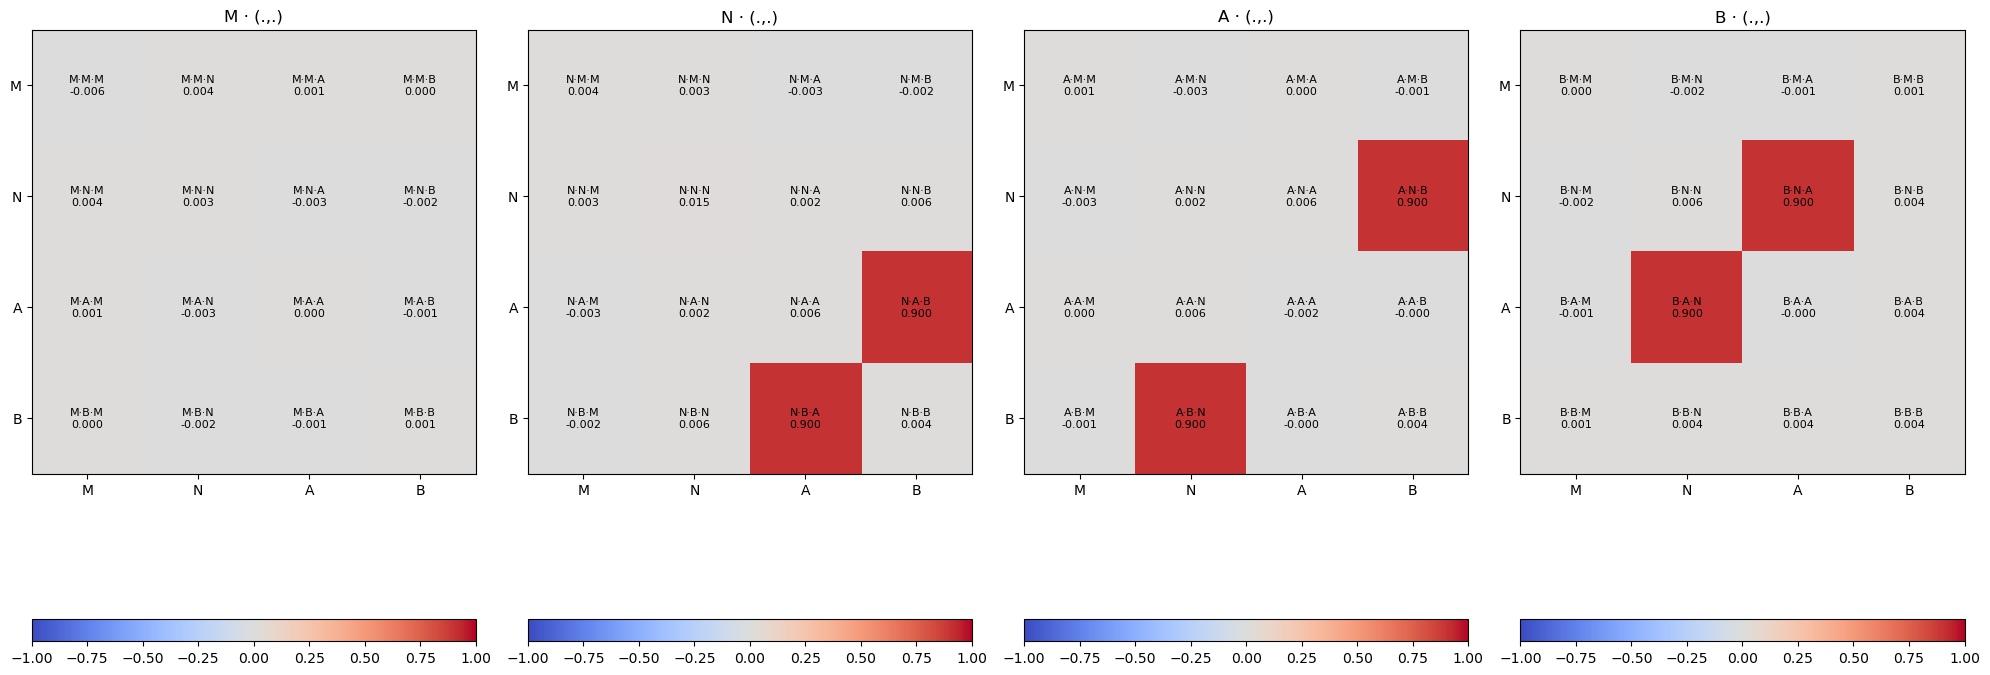

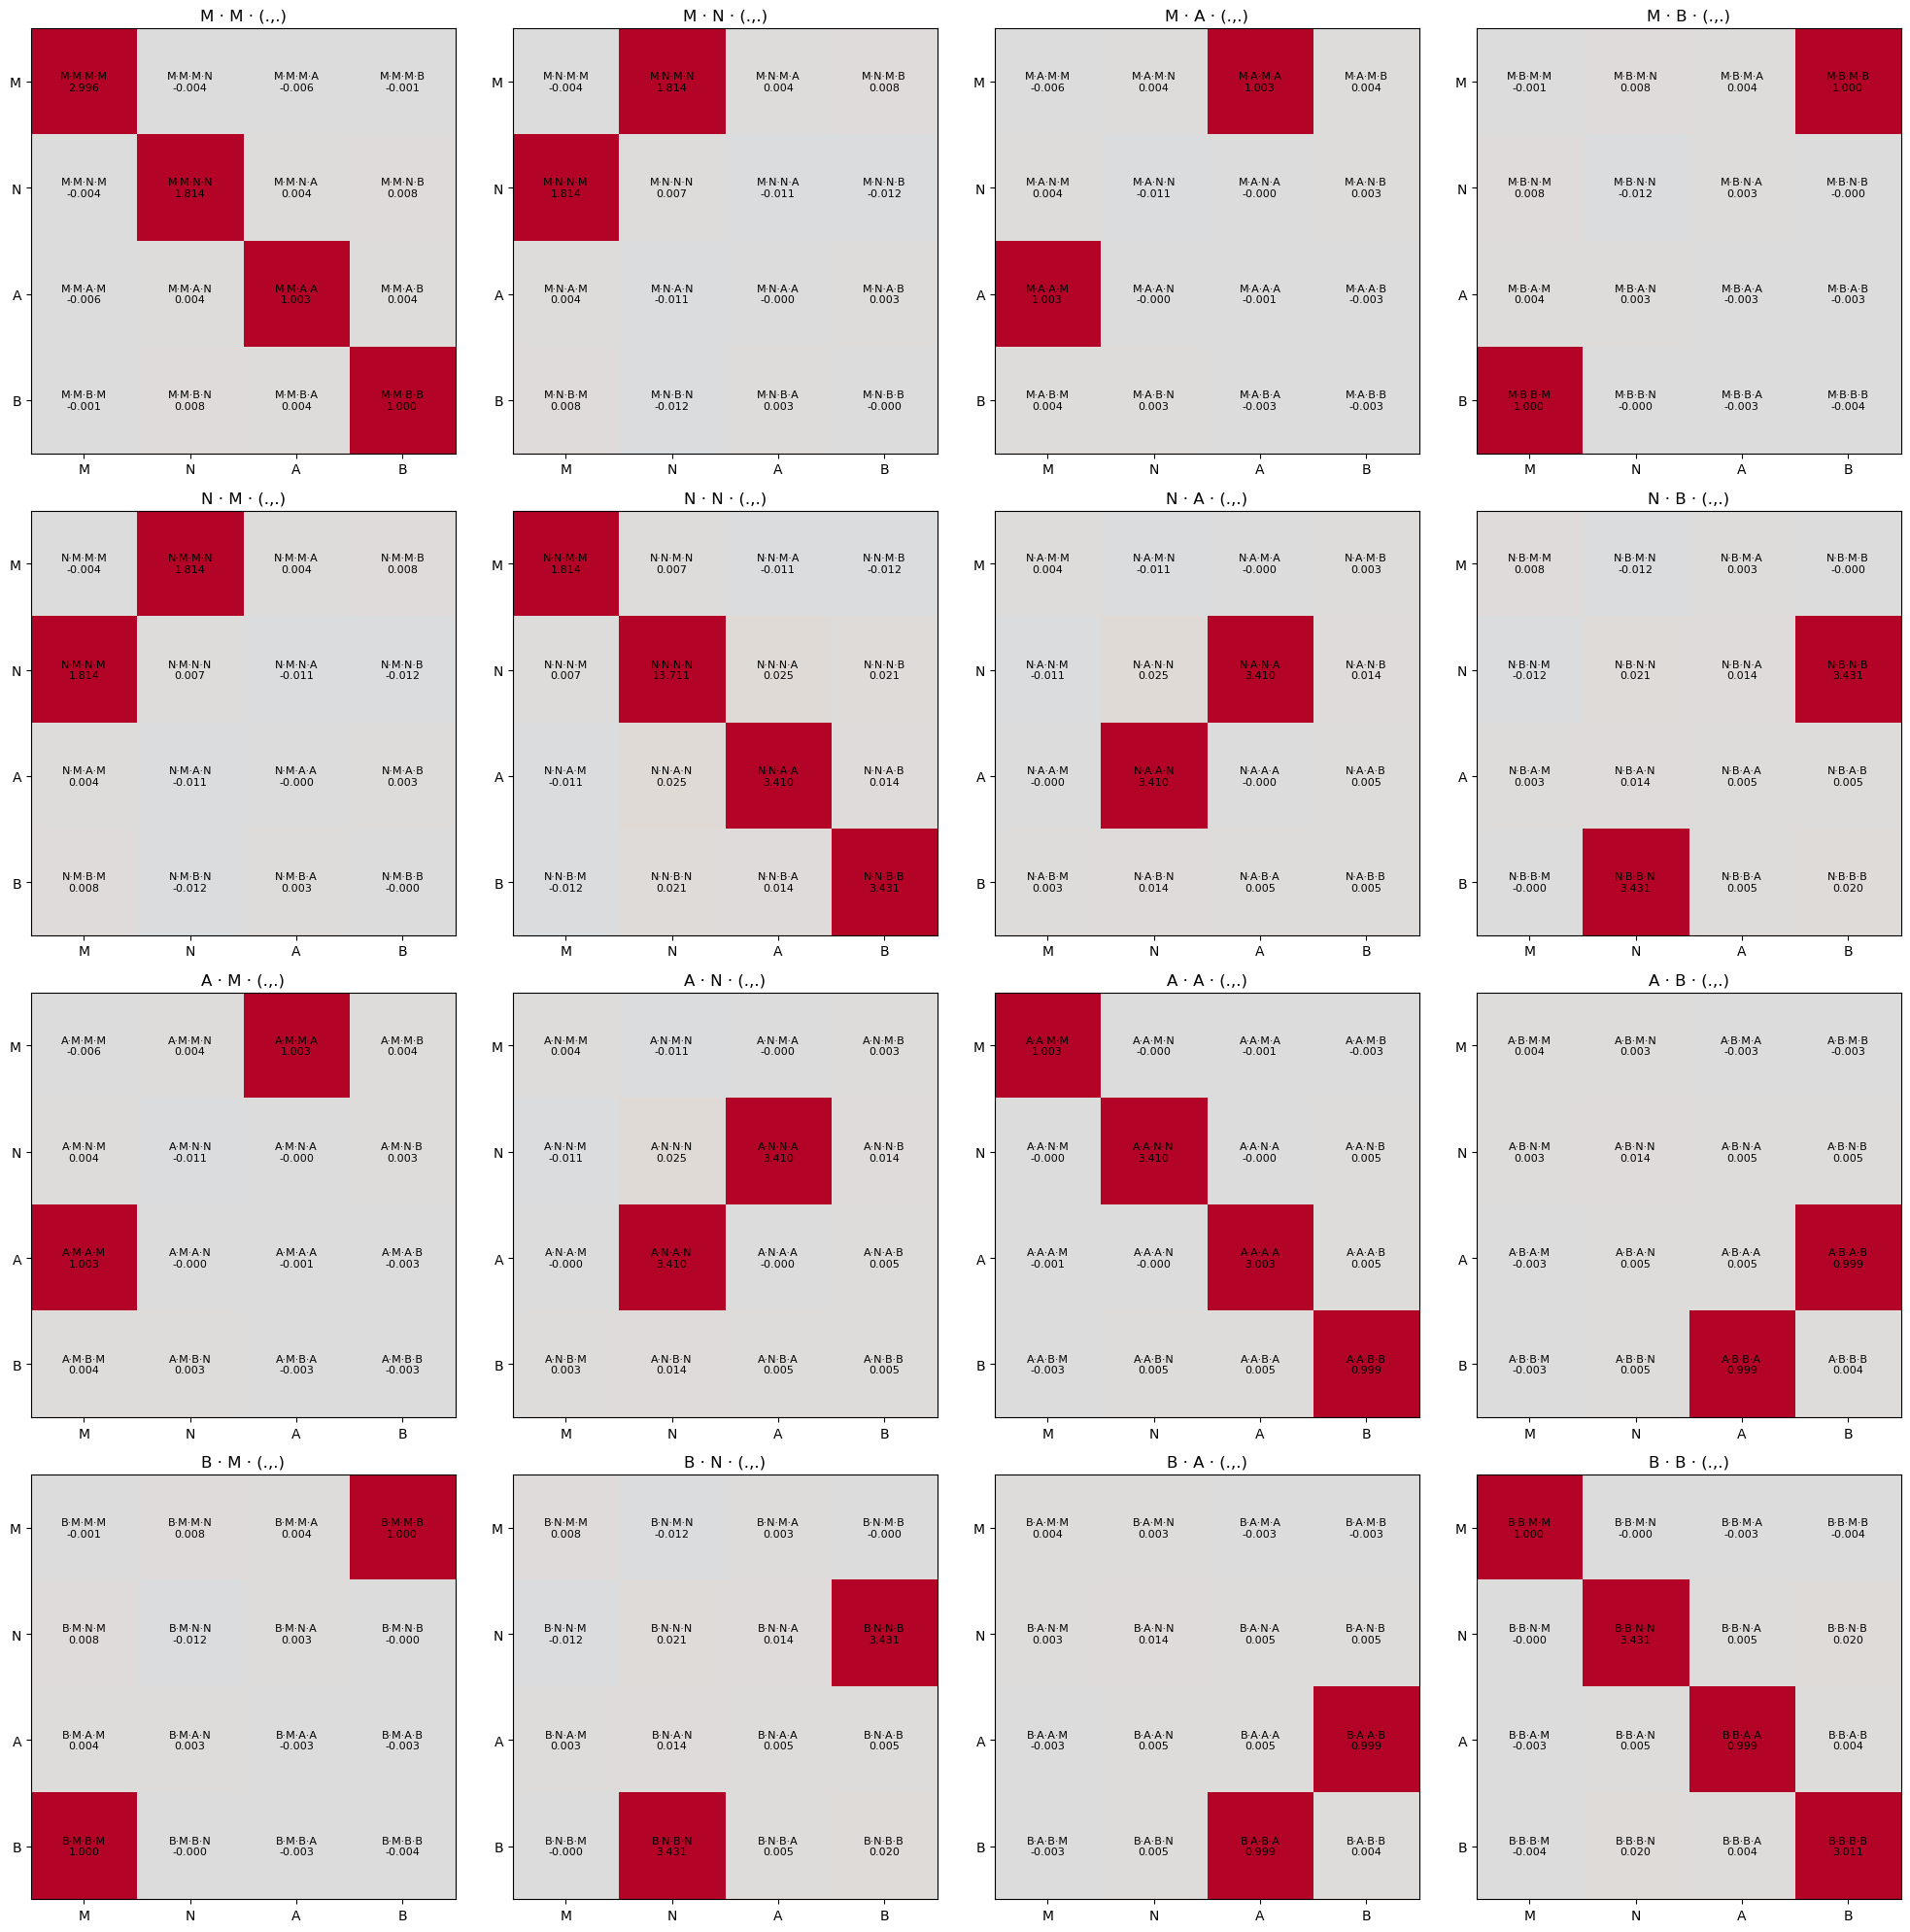

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

S = 100
N = 10000

# phi = lambda x: np.log( 1 + np.exp( x ) )
# d1phi = lambda x: np.exp( x ) / (1 + np.exp( x ))
# d2phi = lambda x: np.exp( x ) / np.square( 1 + np.exp( x ) )
# d3phi = lambda x: ( np.exp( x ) - np.exp( 3*x )) / np.power(1 + np.exp( x ), 4)

phi = lambda x: np.tanh(x)
d1phi = lambda x: 1 - np.tanh(x)**2
d2phi = lambda x: -2*np.tanh(x) + 2*np.tanh(x)**3
d3phi = lambda x: -2 + 8*np.tanh(x)**2 - 6*np.tanh(x)**4
d4phi = lambda x: 16*np.tanh(x) - 40*np.tanh(x)**3 + 24*np.tanh(x)**5

mu_m = 0
mu_n = 0
mu_A = 0
mu_B = 0

sigma_m = 1
sigma_n = 1
sigma_I = 1

rho_mn = 0
rho_mA = 0
rho_mB = 0
rho_nA = 0
rho_nB = 0
rho_AB = 0

rho_nI = 0.9

mu = np.array([mu_m, mu_n, mu_A, mu_B], dtype=np.float64)

cov = np.array([
    [sigma_m**2,                rho_mn*sigma_m*sigma_n,         rho_mA*sigma_m*sigma_I,         rho_mB*sigma_m*sigma_I],
    [rho_mn*sigma_m*sigma_n,    sigma_n**2,                     rho_nA*sigma_n*sigma_I,         rho_nB*sigma_n*sigma_I],
    [rho_mA*sigma_m*sigma_I,    rho_nA*sigma_n*sigma_I,         sigma_A**2,                     rho_AB*sigma_I*sigma_I],
    [rho_mB*sigma_m*sigma_I,    rho_nB*sigma_n*sigma_I,         rho_AB*sigma_I*sigma_I,         sigma_B**2]
], dtype=np.float64)

m, n_perp, I_A, I_B = np.random.multivariate_normal(mean=mu, cov=cov, size=(S,N)).transpose(2, 0, 1)             # (4, S, N)

# bias = np.random.normal(loc=0, scale=1/np.sqrt(N), size=(S,N))
n = n_perp + (rho_nI * I_A * I_B)

X = np.random.normal(loc=0, scale=1/np.sqrt(N), size=(S, N))                                            # (S, N)
K = np.random.normal(loc=0, scale=1/np.sqrt(N), size=(S, ))                                             # (S,)
A = np.sin( np.linspace(0, 2*np.pi, S) )
B = np.cos( np.linspace(0, 2*np.pi, S) )

max_iter = 200
tol = 1e-10
damping = 0.5


errors = []
all_K =[]

for _ in range(max_iter):
    K_new = (1/N)*np.einsum('sj,sj->s', n, phi(X))                                                        # (S,)
    X_new = m*K[:,None] + I_A*A[:,None] + I_B*B[:,None] #+ bias

    K = (1 - damping)*K + damping*K_new
    X = (1 - damping)*X + damping*X_new

    err = np.max(np.abs(
        np.concatenate((
            X_new - X,
            (K_new - K).reshape((S,1))
        ), axis=1)
    ), axis=1).mean()
    errors.append(err)

    all_K.append(K)



all_K = np.stack(all_K, axis=1)
fig, ax = plt.subplots(1, 1, figsize=(10,10))

mean_K = K.mean()
std_K = K.std()
bins = np.linspace(mean_K - 3*std_K, mean_K + 3*std_K, 50)

ax.hist(K, bins=bins, label='DMFT', alpha=0.5)
ax.axvline(x=K.mean())



Y = np.stack([m, n, I_A, I_B], axis=0)   # shape: (4, S, N)

# Pairwise overlaps: shape (4, 4)
Q = np.einsum('asn, bsn -> ab', Y, Y) / (Y.shape[1] * Y.shape[2])

# Ternary overlaps: shape (4, 4, 4)
T = np.einsum('asn, bsn, csn -> abc', Y, Y, Y) / (Y.shape[1] * Y.shape[2])

names = ["M","N","A","B"]
num = len(names)

cmap = colormaps.get_cmap('coolwarm')
from matplotlib.colors import Normalize
norm = Normalize(vmin=-1, vmax=1)

# -------- Pairwise overlaps --------

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(Q, cmap=cmap, norm=norm)

ax.set_xticks(range(num))
ax.set_yticks(range(num))
ax.set_xticklabels(names)
ax.set_yticklabels(names)

ax.set_title("Pairwise overlaps")

for i in range(num):
    for j in range(num):
        ax.text(j, i, f"{names[i]}·{names[j]}\n{Q[i,j]:.3f}",
                ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()


# -------- Ternary overlaps --------

fig, axes = plt.subplots(1, num, figsize=(20,10))

for a, ax in enumerate(axes):

    im = ax.imshow(T[a], cmap=cmap, norm=norm)

    fig.colorbar(im, ax=ax, orientation='horizontal')

    ax.set_xticks(range(num))
    ax.set_yticks(range(num))
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)

    ax.set_title(f"{names[a]} · (.,.)")

    for b in range(num):
        for c in range(num):
            ax.text(c, b,
                    f"{names[a]}·{names[b]}·{names[c]}\n{T[a,b,c]:.3f}",
                    ha="center", va="center", fontsize=8)

plt.tight_layout()

F = np.einsum('asn, bsn, csn, dsn -> abcd', Y, Y, Y, Y) / (Y.shape[1] * Y.shape[2])

fig, axes = plt.subplots(4, 4, figsize=(20,20))

for i in range(4):
    for j in range(4):
        ax = axes[i,j]

        mat = F[i,j]

        im = ax.imshow(mat, cmap=cmap, norm=norm)

        ax.set_xticks(range(num))
        ax.set_yticks(range(num))
        ax.set_xticklabels(names)
        ax.set_yticklabels(names)

        ax.set_title(f"{names[i]} · {names[j]} · (.,.)")

        for k in range(num):
            for l in range(num):
                ax.text(l, k,
                        f"{names[i]}·{names[j]}·{names[k]}·{names[l]}\n{F[i,j,k,l]:.3f}",
                        ha="center", va="center", fontsize=8)

plt.tight_layout()

plt.show()

/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/4118656205.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/4118656205.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/4118656205.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/4118656205.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

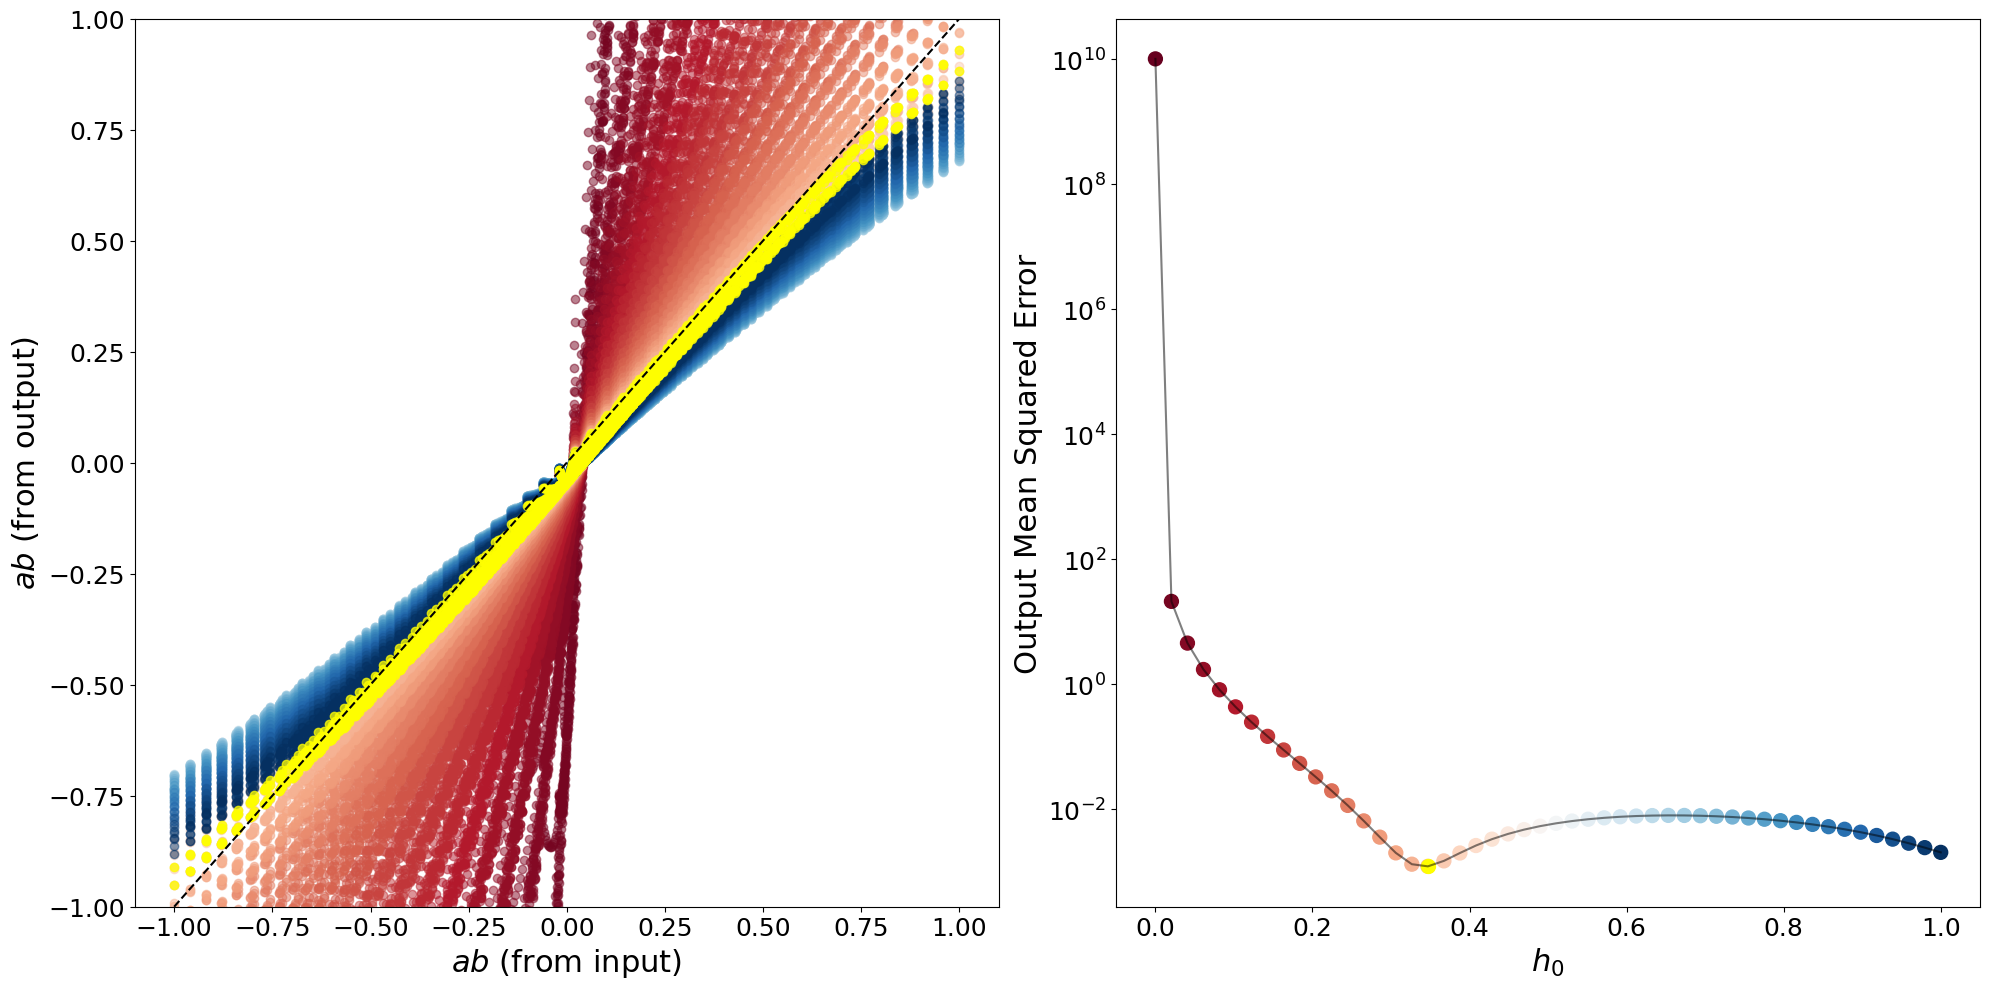

In [123]:
# max_iter = 200
# tol = 1e-10
# damping = 0.7 
# n_h_0 = 50
# n_inputs = 50
# n_neurons = 10000
# min_ab, max_ab = -1, 1

# # phi = lambda x: np.log( 1 + np.exp( x ) )
# # d1phi = lambda x: np.exp( x ) / (1 + np.exp( x ))
# # d2phi = lambda x: np.exp( x ) / np.square( 1 + np.exp( x ) )
# # d3phi = lambda x: ( np.exp( x ) - np.exp( 3*x )) / np.power(1 + np.exp( x ), 4)

# phi = lambda x: np.tanh(x)
# d1phi = lambda x: 1 - np.tanh(x)**2
# d2phi = lambda x: -2*np.tanh(x) + 2*np.tanh(x)**3
# d3phi = lambda x: -2 + 8*np.tanh(x)**2 - 6*np.tanh(x)**4
# d4phi = lambda x: 16*np.tanh(x) - 40*np.tanh(x)**3 + 24*np.tanh(x)**5


# sigma_m = 1
# sigma_n = 0.3
# sigma_I = 0.3
# rho_mn = 0
# rho_nI = 1

# cov = np.diag([sigma_m, sigma_n, sigma_I, sigma_I])**2

# aa, bb = np.meshgrid( np.linspace(-1, 1, n_inputs), np.linspace(-1, 1, n_inputs) )
# aa, bb = aa.flatten(), bb.flatten()

# def make_correlated_samples(L, seed=0):
#     dim = L.shape[0]
#     x = np.random.normal(loc=0, scale=1, size=(dim, n_neurons))
#     z = np.einsum('ij, jn -> in', L, x)    
#     return z


# L = np.linalg.cholesky(cov)
# z = make_correlated_samples(L)

# m = z[0]
# n_perp = z[1]
# IA = z[2]   
# IB = z[3]   
# n = n_perp + (rho_nI/sigma_I**2)*IA*IB

# c = 1


# kappa = np.zeros((n_inputs**2))                    # 2, n_inputs

# for _ in range(max_iter):

#     h = c +\
#         np.einsum('i, u -> iu', m, kappa) +\
#         np.einsum('i, u -> iu', IA, aa) +\
#         np.einsum('i, u -> iu', IB, bb) 

#     kappa_new = (1/n_neurons) * np.einsum('i, iu -> u', n, phi( h ))

#     err = np.max(np.abs(kappa_new - kappa))
#     kappa = damping * kappa_new + (1.0 - damping) * kappa

#     if err < tol:
#         print('converged')
#         break
 


h_0 = np.linspace(1e-6, 1, n_h_0)
w = 1 / (d2phi(h_0) * rho_nI * sigma_I**2)    

est_ab = np.einsum('h, u -> hu', w, kappa)       
target_ab = (aa * bb)[None,:]

error = np.square( est_ab - target_ab ).mean(axis=1)                         # (n_h_0,)

best_h_0 = np.argmin( error )


fig, ax = plt.subplots(1, 2, figsize=(20,10))

cmap = colormaps.get_cmap('RdBu')
norm = Normalize(vmin=h_0[0], vmax=h_0[-1])
for i, h in enumerate(h_0):
    ax[0].scatter(target_ab, est_ab[i], color=cmap(norm(h)), alpha=0.5)
ax[0].scatter(target_ab, est_ab[best_h_0], color='yellow', alpha=0.75)
ax[0].set_ylim((-1, 1))
ax[0].plot(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100), ls='--', color='k')
ax[0].set_xlabel(r'$ab$ (from input)', fontsize=22)
ax[0].set_ylabel(r'$ab$ (from output)', fontsize=22)
ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)

ax[1].plot(h_0, error, c='k', alpha=0.5)
ax[1].scatter(h_0, error, c=cmap(norm(h_0)), s=100)
ax[1].scatter(h_0[ best_h_0 ], error[ best_h_0 ], color='yellow', s=100)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$h_0$', fontsize=22)
ax[1].set_ylabel('Output Mean Squared Error', fontsize=22)
ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
ax[1].set_yticklabels(ax[1].get_yticklabels(), fontsize=18)

plt.tight_layout()

plt.show()

/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/1418227246.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/1418227246.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/1418227246.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_14402/1418227246.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set

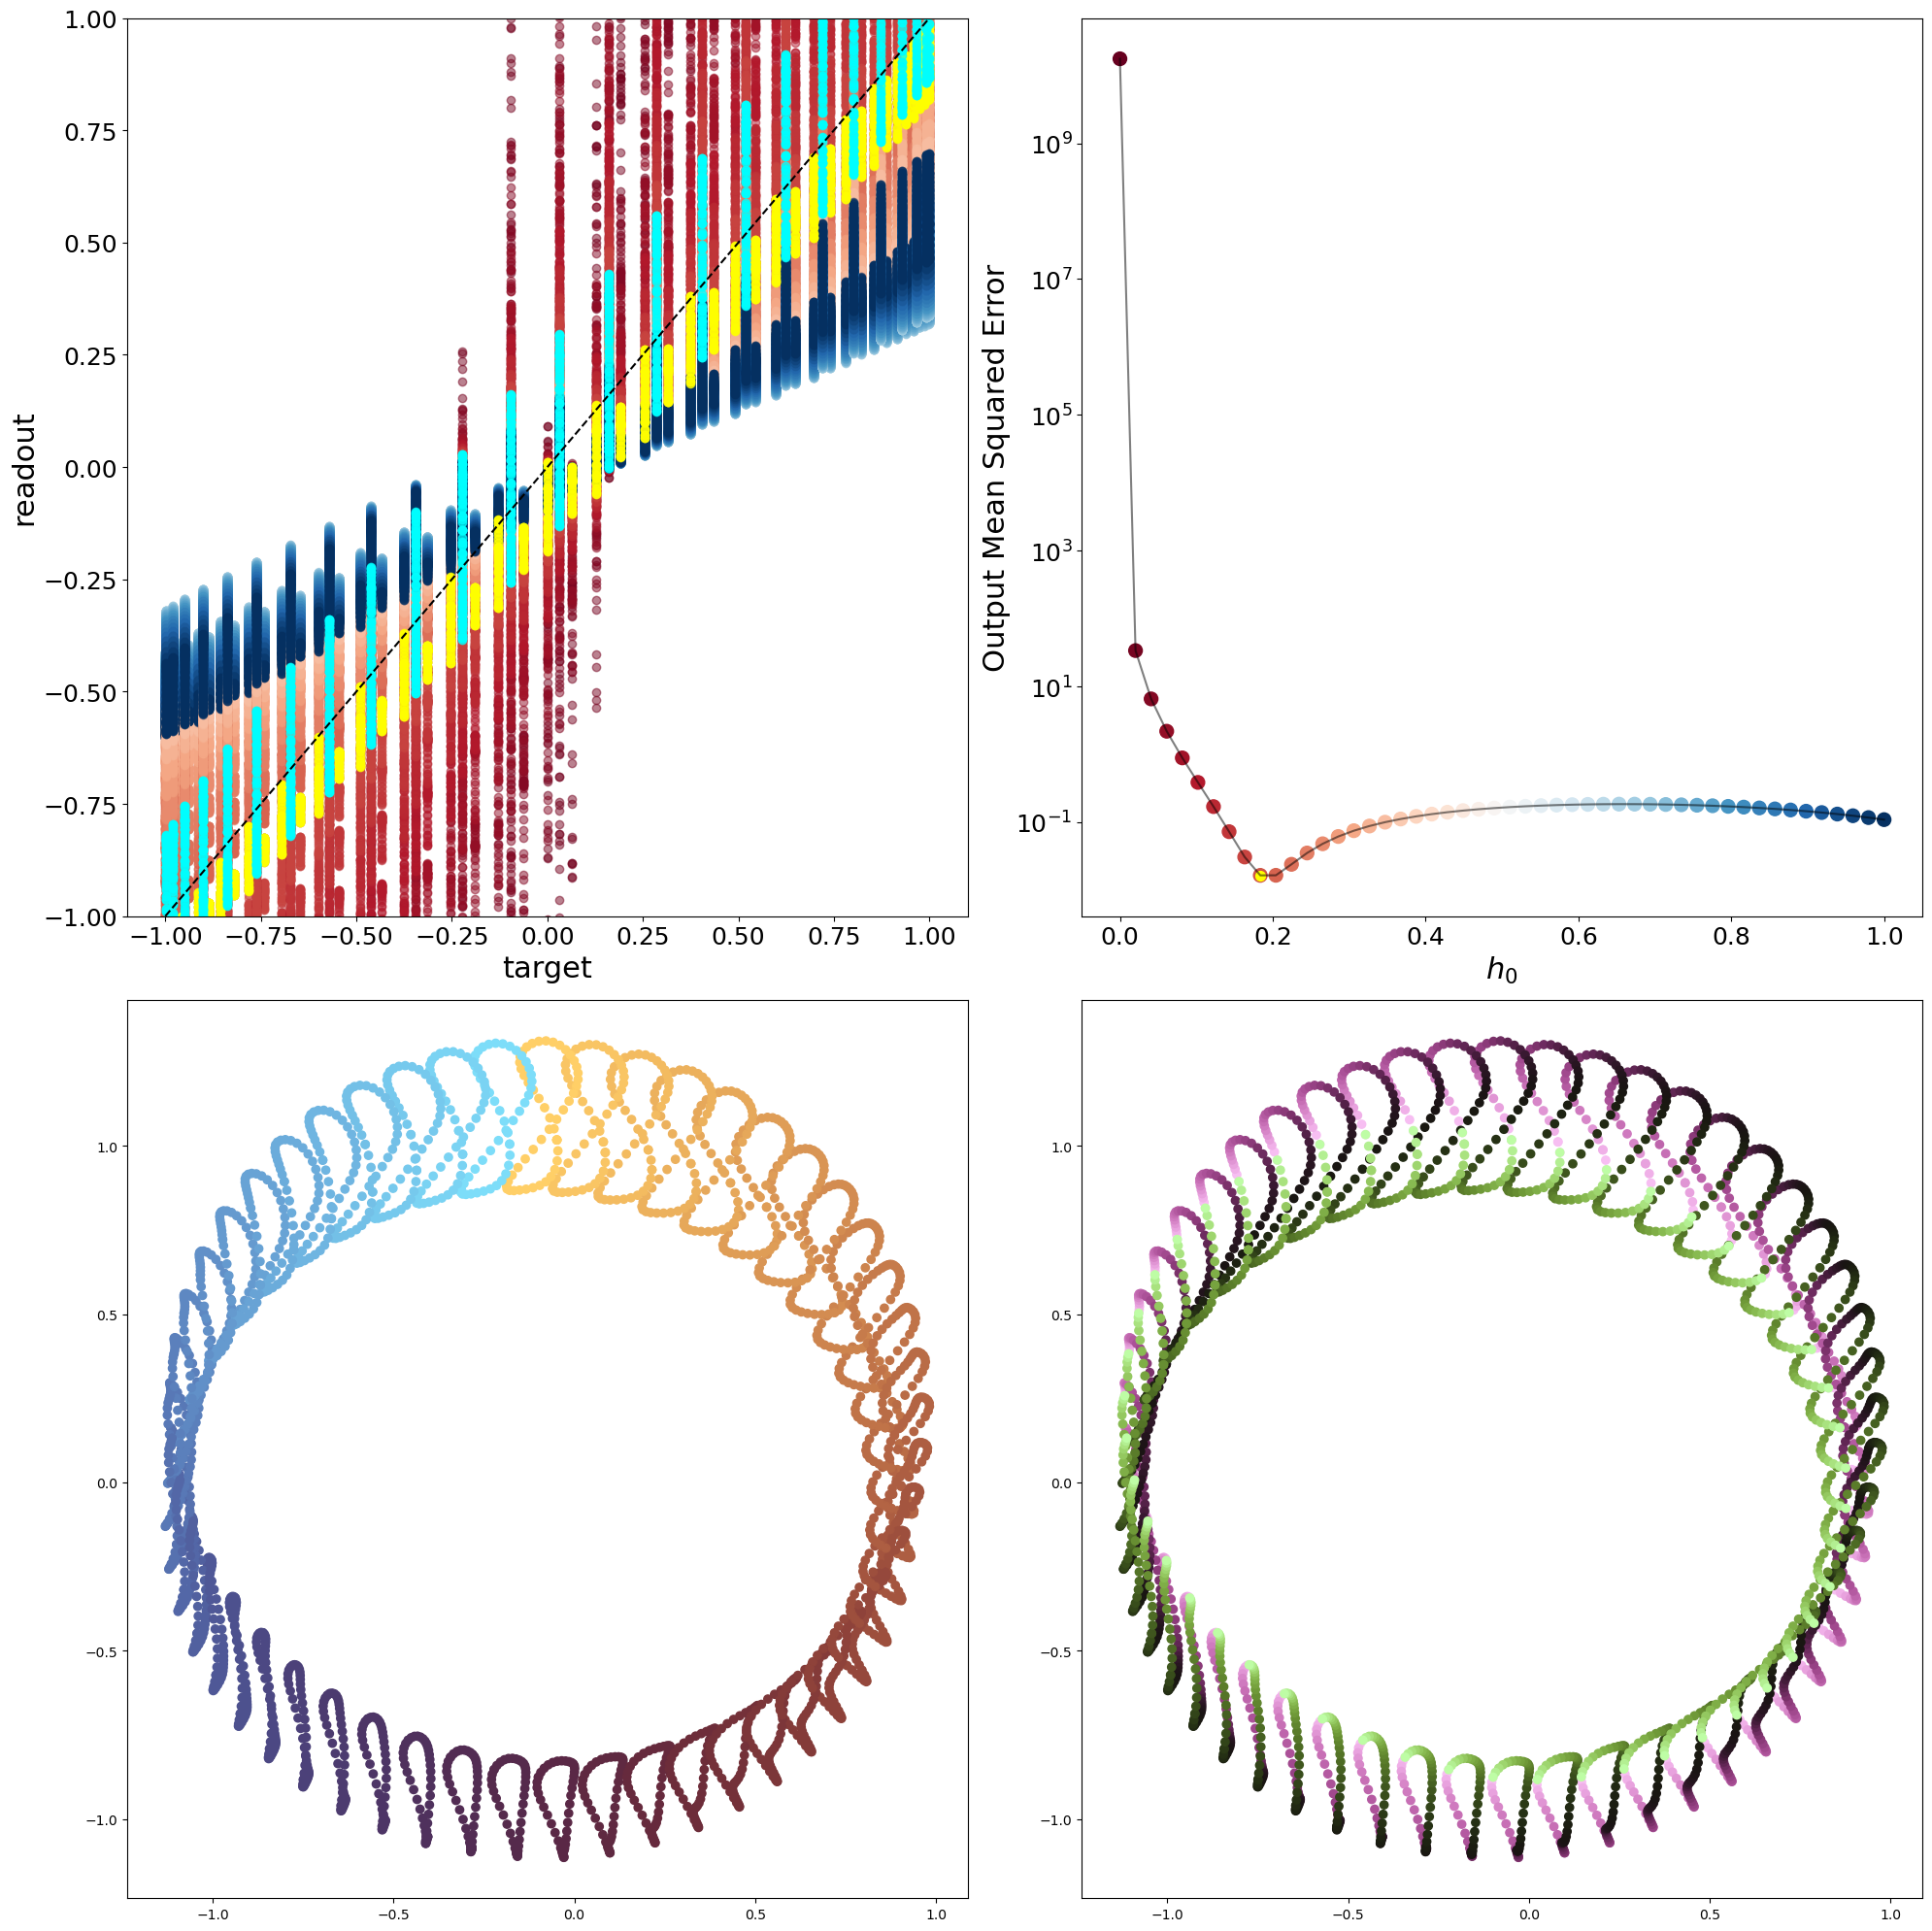

In [157]:
# max_iter = 200
# tol = 1e-10
# damping = 0.7 
# n_h_0 = 50
# n_inputs = 50
# n_neurons = 10000

# # phi = lambda x: np.log( 1 + np.exp( x ) )
# # d1phi = lambda x: np.exp( x ) / (1 + np.exp( x ))
# # d2phi = lambda x: np.exp( x ) / np.square( 1 + np.exp( x ) )
# # d3phi = lambda x: ( np.exp( x ) - np.exp( 3*x )) / np.power(1 + np.exp( x ), 4)

# phi = lambda x: np.tanh(x)
# d1phi = lambda x: 1 - np.tanh(x)**2
# d2phi = lambda x: -2*np.tanh(x) + 2*np.tanh(x)**3
# d3phi = lambda x: -2 + 8*np.tanh(x)**2 - 6*np.tanh(x)**4
# d4phi = lambda x: 16*np.tanh(x) - 40*np.tanh(x)**3 + 24*np.tanh(x)**5


# sigma_m = 0.5
# sigma_n = 0.3
# sigma_I = 0.3
# rho_nI_1 = 1
# rho_nI_2 = 1
# J_1 = 1
# J_2 = 1

# cov = sigma_I**2 * np.eye(4)

# t1, t2 = np.meshgrid( np.linspace(0, 2*np.pi, n_inputs) , np.linspace(0, 2*np.pi, n_inputs))
# t1, t2 = t1.flatten(), t2.flatten()
# U1, U2, U3, U4 = np.sin( t1 ), np.cos( t1 ), np.sin( t2 ), np.cos( t2 )
# T1, T2 = np.sin( t2 - t1 ), np.cos( t2 - t1 )

# def make_correlated_samples(L, seed=0):
#     dim = L.shape[0]
#     x = np.random.normal(loc=0, scale=1, size=(dim, n_neurons))
#     z = np.einsum('ij, jn -> in', L, x)    

#     theta = np.random.uniform(low=0, high=2*np.pi, size=(1, n_neurons))

#     return np.concatenate((theta, z), axis=0)


# L = np.linalg.cholesky(cov)
# z = make_correlated_samples(L)

# m1 = np.sqrt(J_1) *  np.cos( z[0] )
# m2 = np.sqrt(J_2) * np.sin( z[0] )
# n1_perp = np.sqrt(J_1) * np.cos( z[0] )
# n2_perp = np.sqrt(J_2) * np.sin( z[0] )
# I1 = z[1]   
# I2 = z[2]   
# I3 = z[3]
# I4 = z[4]
# n1 = n1_perp + (rho_nI_1 / sigma_I**2)*(I2*I3 - I1*I4)
# n2 = n2_perp + (rho_nI_2 / sigma_I**2)*(I1*I3 + I2*I4)

# c = 0.5


# kappa = np.zeros((2, n_inputs**2))                    # 2, n_inputs
# m = np.stack((m1, m2), axis=0)                        # 2, n_neurons
# n = np.stack((n1, n2), axis=0)                        # 2, n_neurons
# b = np.stack((I1, I2, I3, I4), axis=0)                # 4, n_neurons
# u = np.stack((U1, U2, U3, U4), axis=0)                    # 4, n_inputs

# for _ in range(max_iter):

#     h = c +\
#         np.einsum('ri, ru -> iu', m, kappa) +\
#         np.einsum('ki, ku -> iu', b, u) 

#     kappa_new = (1/n_neurons) * np.einsum('ri, iu -> ru', n, phi( h ))

#     err = np.max(np.abs(kappa_new - kappa))
#     kappa = damping * kappa_new + (1.0 - damping) * kappa

#     if err < tol:
#         print('converged')
#         break
 


h_0 = np.linspace(1e-6, 1, n_h_0)

w1 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_1) / (d2phi(h_0) * rho_nI_1 * sigma_I**2)  
w2 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_2) / (d2phi(h_0) * rho_nI_2 * sigma_I**2)    
w = np.stack((w1, w2), axis=1)

pred = np.einsum('hr, ru -> hru', w, kappa)       
target = np.stack((T1, T2), axis=0)

error = np.square( pred - target[None,:,:] ).mean(axis=(1,2))                         # (n_h_0,)

best_h_0 = np.argmin( error )


from matplotlib.cm import ScalarMappable
fig, ax = plt.subplots(2, 2, figsize=(20,20))
ax = ax.flatten()


cmap = colormaps.get_cmap('RdBu')
norm = Normalize(vmin=h_0[0], vmax=h_0[-1])
for k in range(2):
    for i, h in enumerate(h_0):
        ax[0].scatter(target[k], pred[i,k], color=cmap(norm(h)), alpha=0.5)
for k in range(2):
    ax[0].scatter(target[k], pred[best_h_0, k], color=['yellow', 'cyan'][k], alpha=0.75)
ax[0].set_ylim((-1, 1))
ax[0].plot(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100), ls='--', color='k')
ax[0].set_xlabel(r'target', fontsize=22)
ax[0].set_ylabel(r'readout', fontsize=22)
ax[0].set_xticklabels(ax[0].get_xticklabels(), fontsize=18)
ax[0].set_yticklabels(ax[0].get_yticklabels(), fontsize=18)

ax[1].plot(h_0, error, c='k', alpha=0.5)
ax[1].scatter(h_0, error, c=cmap(norm(h_0)), s=100)
ax[1].scatter(h_0[ best_h_0 ], error[ best_h_0 ], color='yellow', s=50)
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$h_0$', fontsize=22)
ax[1].set_ylabel('Output Mean Squared Error', fontsize=22)
ax[1].set_xticklabels(ax[1].get_xticklabels(), fontsize=18)
ax[1].set_yticklabels(ax[1].get_yticklabels(), fontsize=18)

t1_cmap = colormaps.get_cmap('managua')
t2_cmap = colormaps.get_cmap('vanimo')
angle_norm = Normalize(vmin=0, vmax=2*np.pi)
ax[2].scatter(pred[best_h_0,0], pred[best_h_0,1], c=t1_cmap(angle_norm((t2 - t1)%(2*np.pi))))
ax[3].scatter(pred[best_h_0,0], pred[best_h_0,1], c=t2_cmap(angle_norm(t2)))

plt.tight_layout()

plt.show()

In [ ]:
max_iter = 200
tol = 1e-10
damping = 0.7 
n_h_0 = 50
n_inputs = 50
n_neurons = 1000
n_samples = 100
n_epochs = 100
lr = 0.01

phi = lambda x: torch.tanh(x)
d1phi = lambda x: 1 - torch.tanh(x)**2
d2phi = lambda x: -2*torch.tanh(x) + 2*torch.tanh(x)**3
d3phi = lambda x: -2 + 8*torch.tanh(x)**2 - 6*torch.tanh(x)**4
d4phi = lambda x: 16*torch.tanh(x) - 40*torch.tanh(x)**3 + 24*torch.tanh(x)**5

t1, t2 = torch.meshgrid( torch.linspace(0, 2*torch.pi, n_inputs) , torch.linspace(0, 2*torch.pi, n_inputs))
t1, t2 = t1.flatten(), t2.flatten()
U1, U2, U3, U4 = torch.sin( t1 ), torch.cos( t1 ), torch.sin( t2 ), torch.cos( t2 )
T1, T2 = torch.sin( t2 - t1 ), torch.cos( t2 - t1 )

sigma_I = torch.tensor([1], requires_grad=True, dtype=torch.float32)
rho_nI_1 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
rho_nI_2 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
J_1 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
J_2 = torch.tensor([1], requires_grad=True, dtype=torch.float32)
h_0 = torch.tensor([1], requires_grad=True, dtype=torch.float32)

def make_correlated_samples(L):
    dim = L.shape[0]
    x = torch.randn(size=(dim, n_samples, n_neurons))
    z = torch.einsum('ij, jsn -> isn', L, x)    

    theta = torch.rand(size=(1, n_samples, n_neurons)) * 2*np.pi

    return torch.concatenate((theta, z), axis=0)

for e in range(n_epochs):
    cov = sigma_I**2 * torch.eye(4)
    L = torch.linalg.cholesky(cov)
    z = make_correlated_samples(L)

    m1 = torch.sqrt(J_1) *  torch.cos( z[0] )
    m2 = torch.sqrt(J_2) * torch.sin( z[0] )
    n1_perp = torch.sqrt(J_1) * torch.cos( z[0] )
    n2_perp = torch.sqrt(J_2) * torch.sin( z[0] )
    I1 = z[1]   
    I2 = z[2]   
    I3 = z[3]
    I4 = z[4]
    n1 = n1_perp + (rho_nI_1 / sigma_I**2)*(I2*I3 - I1*I4)
    n2 = n2_perp + (rho_nI_2 / sigma_I**2)*(I1*I3 + I2*I4)

    c = 0.5


    kappa = torch.zeros((2, n_samples, n_inputs**2))         # 2, n_samples, n_inputs
    m = torch.stack((m1, m2), axis=0)                        # 2, n_samples, n_neurons
    n = torch.stack((n1, n2), axis=0)                        # 2, n_samples, n_neurons
    b = torch.stack((I1, I2, I3, I4), axis=0)                # 4, n_samples, n_neurons
    u = torch.stack((U1, U2, U3, U4), axis=0)                # 4, n_inputs

    for _ in range(max_iter):

        h = c +\
            torch.einsum('rsi, rsu -> isu', m, kappa) +\
            torch.einsum('ksi, ku -> isu', b, u) 

        kappa_new = (1/n_neurons) * torch.einsum('rsi, isu -> rsu', n, phi( h ))

        err = torch.max(torch.abs(kappa_new - kappa))
        kappa = damping * kappa_new + (1.0 - damping) * kappa

        if err < tol:
            break
    

    w1 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_1) / (d2phi(h_0) * rho_nI_1 * sigma_I**2)  
    w2 = (1 - 0.5*(d1phi(h_0) - d2phi(h_0)*h_0) * J_2) / (d2phi(h_0) * rho_nI_2 * sigma_I**2)    
    w = torch.stack((w1, w2), dim=0)

    pred = torch.einsum('r, rsu -> rsu', w, kappa)       
    target = torch.stack((T1, T2), axis=0)

    error = torch.square( pred - target[:,None,:] ).mean()                         


    error.backward()
    with torch.no_grad():
        for p in [sigma_I, rho_nI_1, rho_nI_2, J_1, J_2, h_0]:
            p -= lr * p.grad
            p.grad.zero_()

    print(f'[{e}] {error:.4f}')


In [141]:
kappa[0].shape

(2500,)

In [ ]:
max_iter = 200
tol = 1e-10
damping = 0.7 
n_inputs = 250
min_ab, max_ab = -1, 1
n_h_0 = 50

def make_correlated_samples(L, n_power=6, seed=0):
    dim = L.shape[0]
    x = np.random.normal(loc=0, scale=1, size=(dim, 2**n_power))
    z = L@x        
    return z

L = np.linalg.cholesky(cov)
z = make_correlated_samples(L, n_power=14)

m  = z[0]  
n_perp  = z[1]
IA = z[2]   
IB = z[3]   
n = n_perp + rho_nI*IA*IB

c = 0.5

theta = np.linspace(0, 2*np.pi, n_inputs)
aa, bb = np.sin(theta), np.cos(theta)


K = np.zeros_like(aa)
for _ in range(max_iter):

    h = K*m[:,None] + aa*IA[:,None] + bb*IB[:,None] + c

    K_new = (n[:,None] * phi(h)).mean(axis=0)

    err = np.max(np.abs(K_new - K))
    K = damping * K_new + (1.0 - damping) * K

    if err < tol:
        break
 
from matplotlib.cm import ScalarMappable


h_0 = np.linspace(-1, 1, n_h_0)
w = 1 / (d2phi(h_0) * rho_nI)    

est_ab = np.einsum('h, s -> hs', w, K)

error = np.abs( est_ab - (aa*bb)[None,:] ).mean(axis=1)                         # (n_h_0)

best_h_0 = np.argmin( error )

fig, ax = plt.subplots(1, 3, figsize=(20,10))

ax[0].plot(h_0, w)
ax[0].set_yscale('log')

cmap = colormaps.get_cmap('RdBu')
norm = Normalize(vmin=h_0[0], vmax=h_0[-1])
for i, h in enumerate(h_0):
    ax[1].scatter(aa*bb, est_ab[i], color=cmap(norm(h)), alpha=0.5)
ax[1].scatter(aa*bb, est_ab[best_h_0], color='yellow', alpha=0.75)

sm = ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=ax[1], orientation='horizontal')
ax[1].set_ylim(((aa*bb).min(), (aa*bb).max()))
ax[1].plot(np.linspace((aa*bb).min(), (aa*bb).max(), 100), np.linspace((aa*bb).min(), (aa*bb).max(), 100), ls='--', color='k')

ax[2].plot(h_0, error)
ax[2].scatter(h_0[ best_h_0 ], error[ best_h_0 ], color='yellow', s=50)
ax[2].set_yscale('log')



In [29]:
import torch 
import numpy as np

B = 100
min_ab = -1
max_ab = 1
n_inputs = 25
n_epochs = 25000
anneal_exp = 1
max_lr = 0.1
lr = max_lr - max_lr*np.exp( -np.linspace(0, 1, n_epochs) * anneal_exp )

phi = lambda x: torch.tanh(x)
d1phi = lambda x: 1 - torch.tanh(x)**2
d2phi = lambda x: -2*torch.tanh(x) + 2*torch.tanh(x)**3
d3phi = lambda x: -2 + 8*torch.tanh(x)**2 - 6*torch.tanh(x)**4

sigma_m = torch.randn((B,), requires_grad=True)
sigma_n = torch.randn((B,), requires_grad=True)
sigma_I = torch.randn((B,), requires_grad=True)
rho_mn = torch.randn((B,), requires_grad=True)
h_0 = torch.randn((B,), requires_grad=True)

params = [
    sigma_m, sigma_n, sigma_I, rho_mn, h_0
]

aa, bb = torch.meshgrid(torch.linspace(min_ab, max_ab, 25), torch.linspace(min_ab, max_ab, n_inputs), indexing='ij')
aa, bb = aa.flatten(), bb.flatten()

def w():
    _sigma_m = sigma_m[None,:]
    _sigma_n = sigma_n[None,:]
    _sigma_I = sigma_I[None,:]
    _rho_mn = rho_mn[None,:]
    _h_0 = h_0[None,:]

    return (1 - _sigma_m * _sigma_n * _rho_mn * (d1phi(_h_0) - d2phi(_h_0)*_h_0)) / (_sigma_I**2 * d2phi(_h_0))

def c1():
    _sigma_m = sigma_m[None,:]
    _sigma_n = sigma_n[None,:]
    _sigma_I = sigma_I[None,:]
    _rho_mn = rho_mn[None,:]
    _h_0 = h_0[None,:]
    _aa = aa[:,None]
    _bb = bb[:,None]

    return (1/2) * (_sigma_m * _sigma_n * _rho_mn) * d3phi(_h_0) * (_h_0**2 + _sigma_I**2 * _aa**2 + _sigma_I**2 * _bb**2)

def c2():
    _sigma_I = sigma_I[None,:]
    _h_0 = h_0[None,:]

    return d3phi(_h_0) * _sigma_I**2 * _h_0

lam = 1
for e in range(n_epochs):

    coef = (1 - c1()) / (1 - w()*c2())
    error = (1 - coef).square().mean()
    var = sigma_m.var() + sigma_n.var() + sigma_I.var() + rho_mn.var() + h_0.var()

    loss = error + lam*var
    loss.backward()

    if torch.isnan(loss):
        print('nan')
        break

    if e%100 == 0:
        print(f'[{e}] {loss:.4f} | {error:.4f} | {var:.4f}')

    with torch.no_grad():
        for p in params:
            p -= lr[e] * p.grad
            p.grad.zero_()

[0] 185.6989 | 180.4598 | 5.2391
[100] 8.9079 | 3.6576 | 5.2503
[200] 7.1468 | 1.8940 | 5.2527
[300] 6.5664 | 1.3205 | 5.2459
[400] 6.2683 | 1.0382 | 5.2301
[500] 6.0764 | 0.8708 | 5.2056
[600] 5.9333 | 0.7605 | 5.1728
[700] 5.8147 | 0.6827 | 5.1320
[800] 5.7086 | 0.6249 | 5.0836
[900] 5.6084 | 0.5804 | 5.0279
[1000] 5.5103 | 0.5450 | 4.9653
[1100] 5.4123 | 0.5161 | 4.8962
[1200] 5.3130 | 0.4919 | 4.8210
[1300] 5.2116 | 0.4715 | 4.7402
[1400] 5.1079 | 0.4538 | 4.6541
[1500] 5.0016 | 0.4384 | 4.5633
[1600] 4.8929 | 0.4248 | 4.4682
[1700] 4.7818 | 0.4126 | 4.3692
[1800] 4.6687 | 0.4016 | 4.2670
[1900] 4.5537 | 0.3917 | 4.1620
[2000] 4.4373 | 0.3826 | 4.0547
[2100] 4.3197 | 0.3743 | 3.9455
[2200] 4.2015 | 0.3665 | 3.8350
[2300] 4.0829 | 0.3593 | 3.7236
[2400] 3.9643 | 0.3525 | 3.6118
[2500] 3.8462 | 0.3461 | 3.5001
[2600] 3.7287 | 0.3399 | 3.3888
[2700] 3.6123 | 0.3339 | 3.2783
[2800] 3.4970 | 0.3280 | 3.1690
[2900] 3.3833 | 0.3222 | 3.0611
[3000] 3.2714 | 0.3164 | 2.9550
[3100] 3.1616 | 

In [ ]:
from sklearn.cluster import KMeans

X = torch.stack(params, dim=1).detach().numpy()
cluster = KMeans(n_clusters=6, verbose=1, n_init=1).fit(X)
cluster.labels_

/Users/jakelaherty/miniforge3/envs/O2S/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


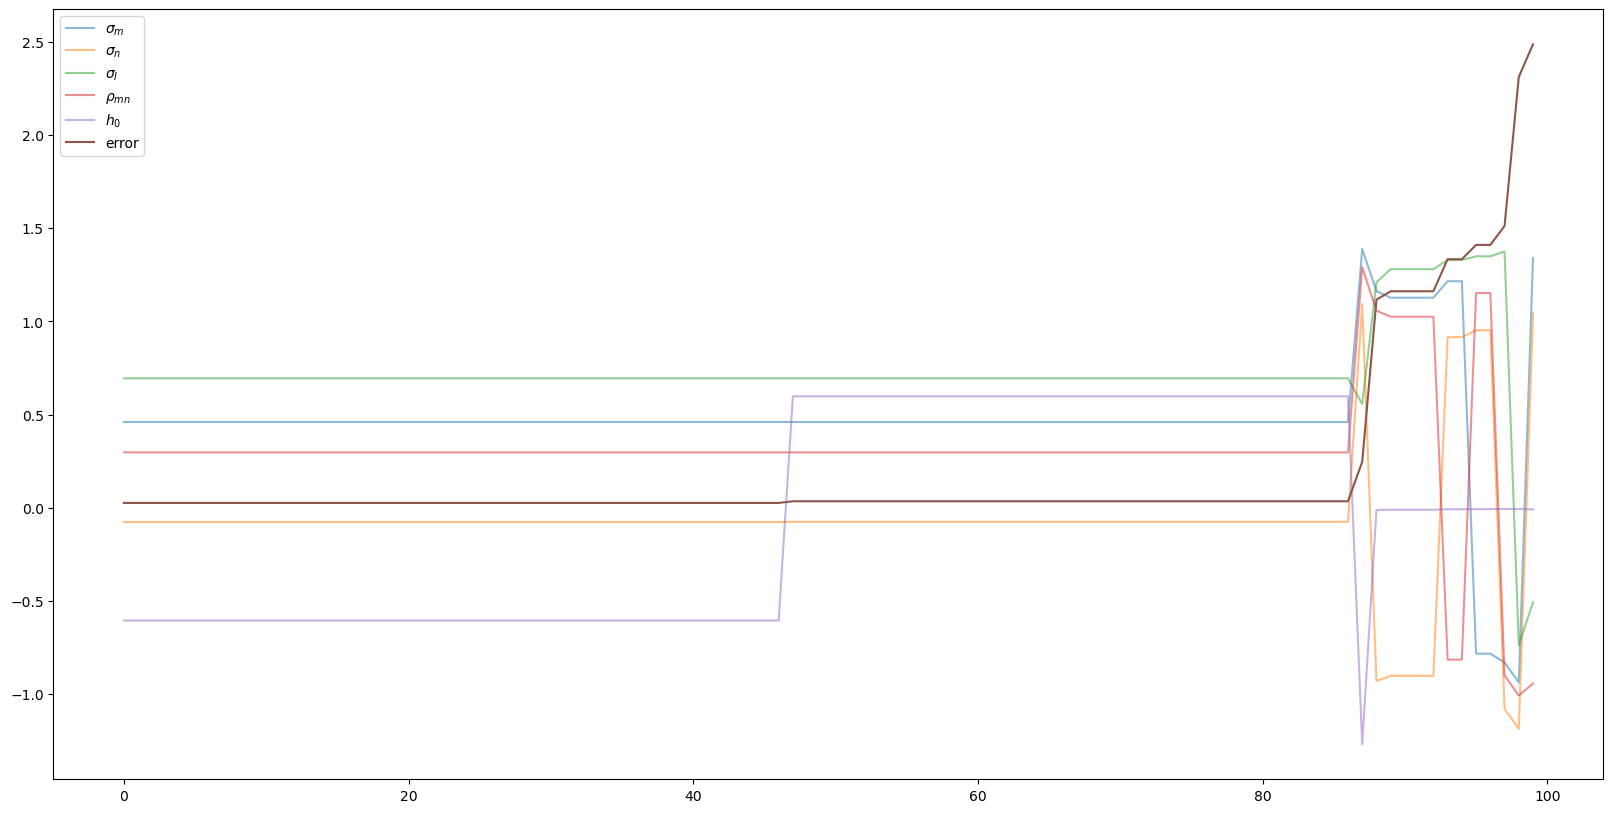

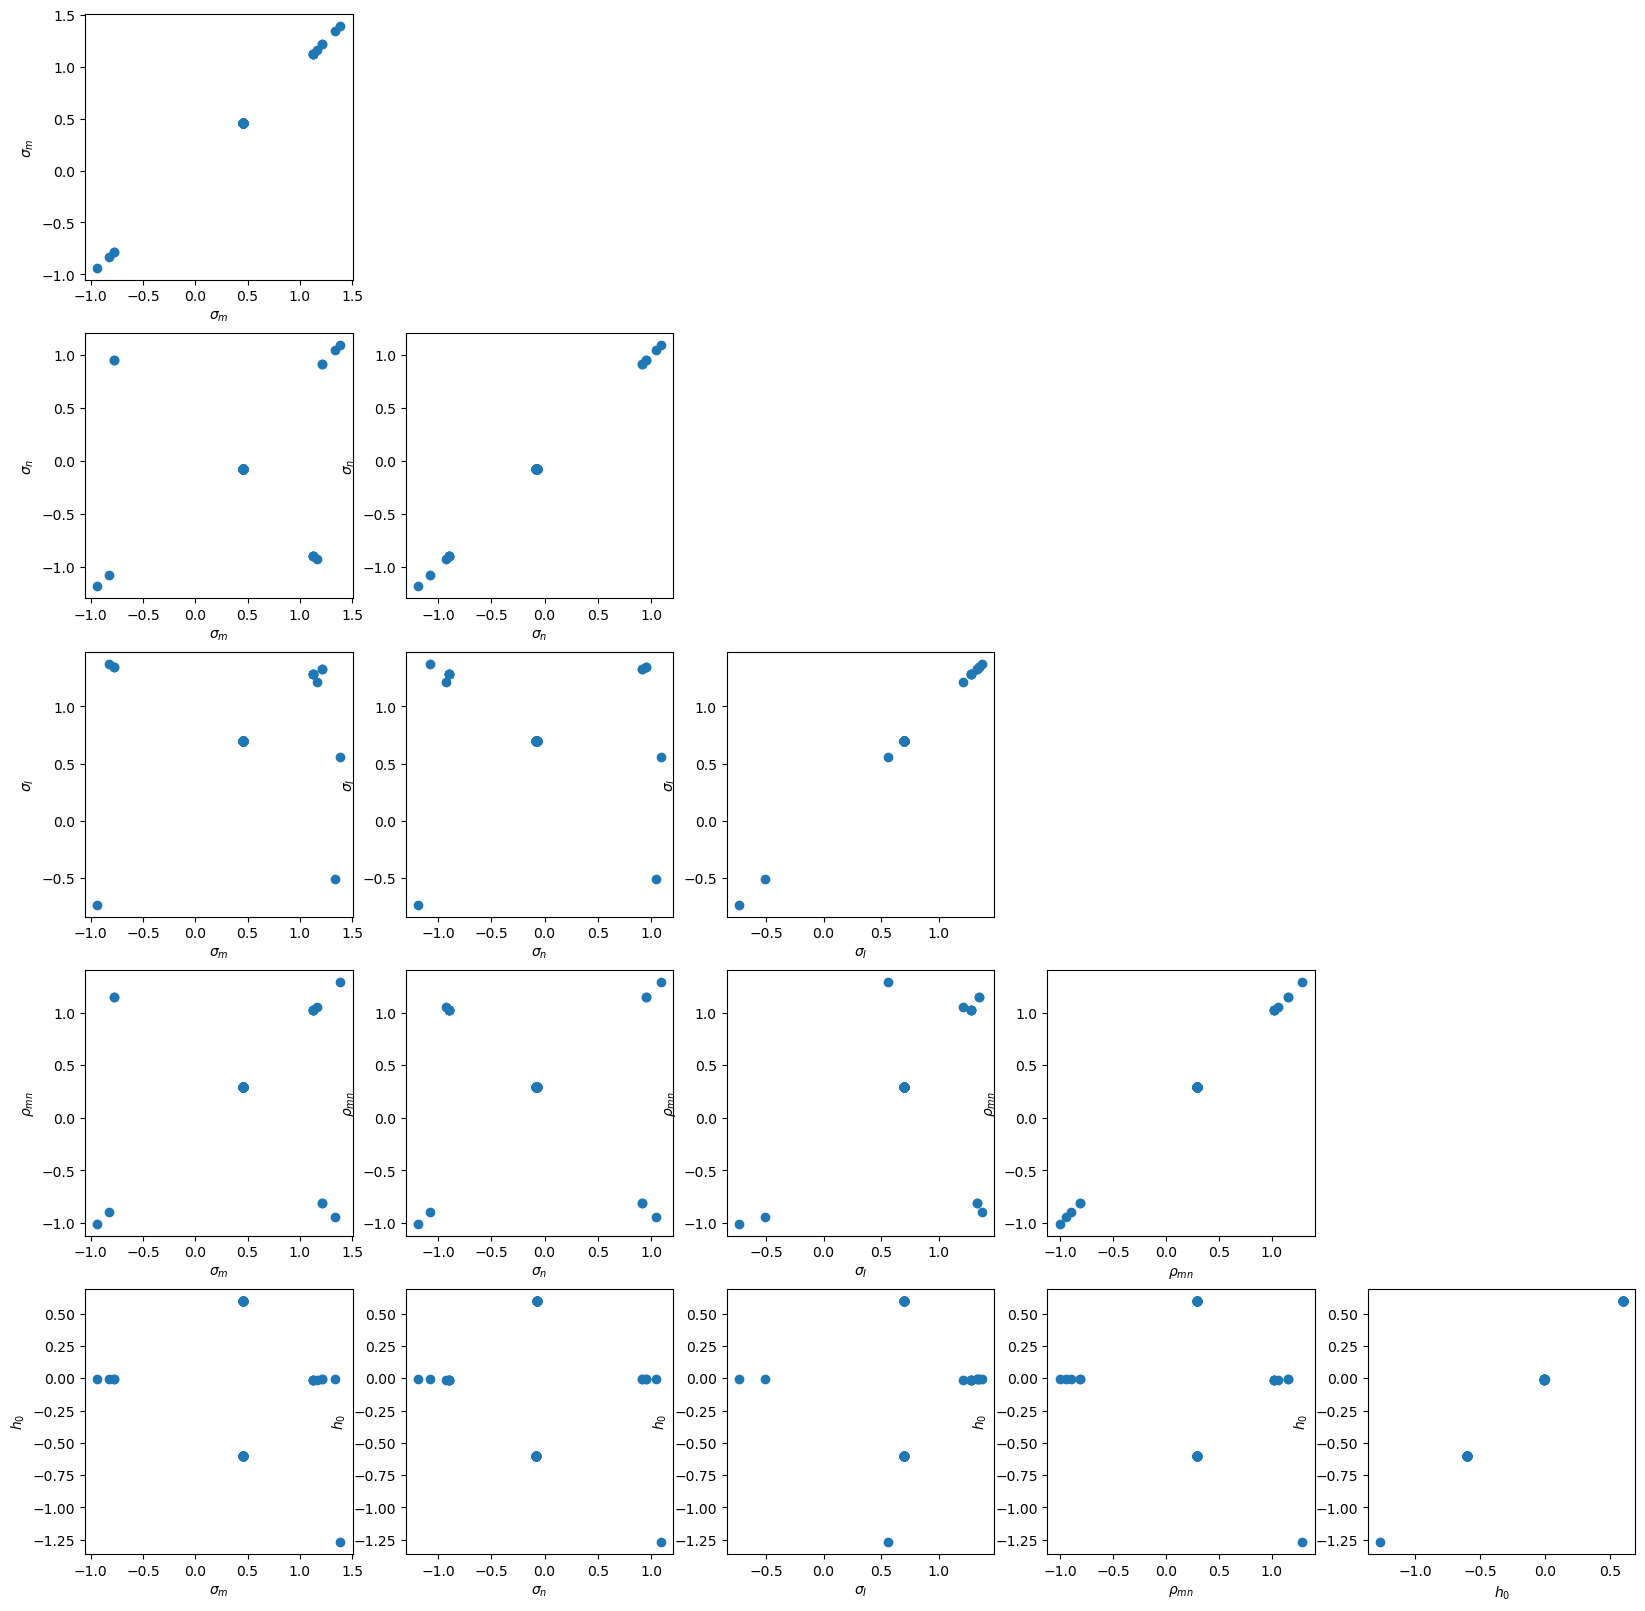

In [30]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

fig, ax = plt.subplots(1, 1, figsize=(20,10))

with torch.no_grad():
    coef = (1 - c1()) / (1 - w()*c2())
    error = (1 - coef).square().mean(dim=0)

    order = np.argsort(error.detach().numpy())

    ax.plot(sigma_m.detach().numpy()[order], label=r'$\sigma_m$', alpha=0.5)
    ax.plot(sigma_n.detach().numpy()[order], label=r'$\sigma_n$', alpha=0.5)
    ax.plot(sigma_I.detach().numpy()[order], label=r'$\sigma_I$', alpha=0.5)
    ax.plot(rho_mn.detach().numpy()[order], label=r'$\rho_{mn}$', alpha=0.5)
    ax.plot(h_0.detach().numpy()[order], label=r'$h_0$', alpha=0.5)
    ax.plot(error.detach().numpy()[order], label='error')
    # ax.plot(w().squeeze().numpy()[order], label=r'$w$')

    ax.legend()

fig, axes = plt.subplots(5, 5, figsize=(20,20))

labels = [r'$\sigma_m$', r'$\sigma_n$', r'$\sigma_I$', r'$\rho_{mn}$', r'$h_0$']
for i in range(5):
    for j in range(5):
        ax = axes[i,j]
        if j > i:
            ax.set_axis_off()
            continue

        ax.scatter(params[j].detach(), params[i].detach())
        ax.set_xlabel(labels[j])
        ax.set_ylabel(labels[i])

usable optimisations: 91
torch.Size([91]) torch.Size([625, 91])


(-1.0, 1.0)

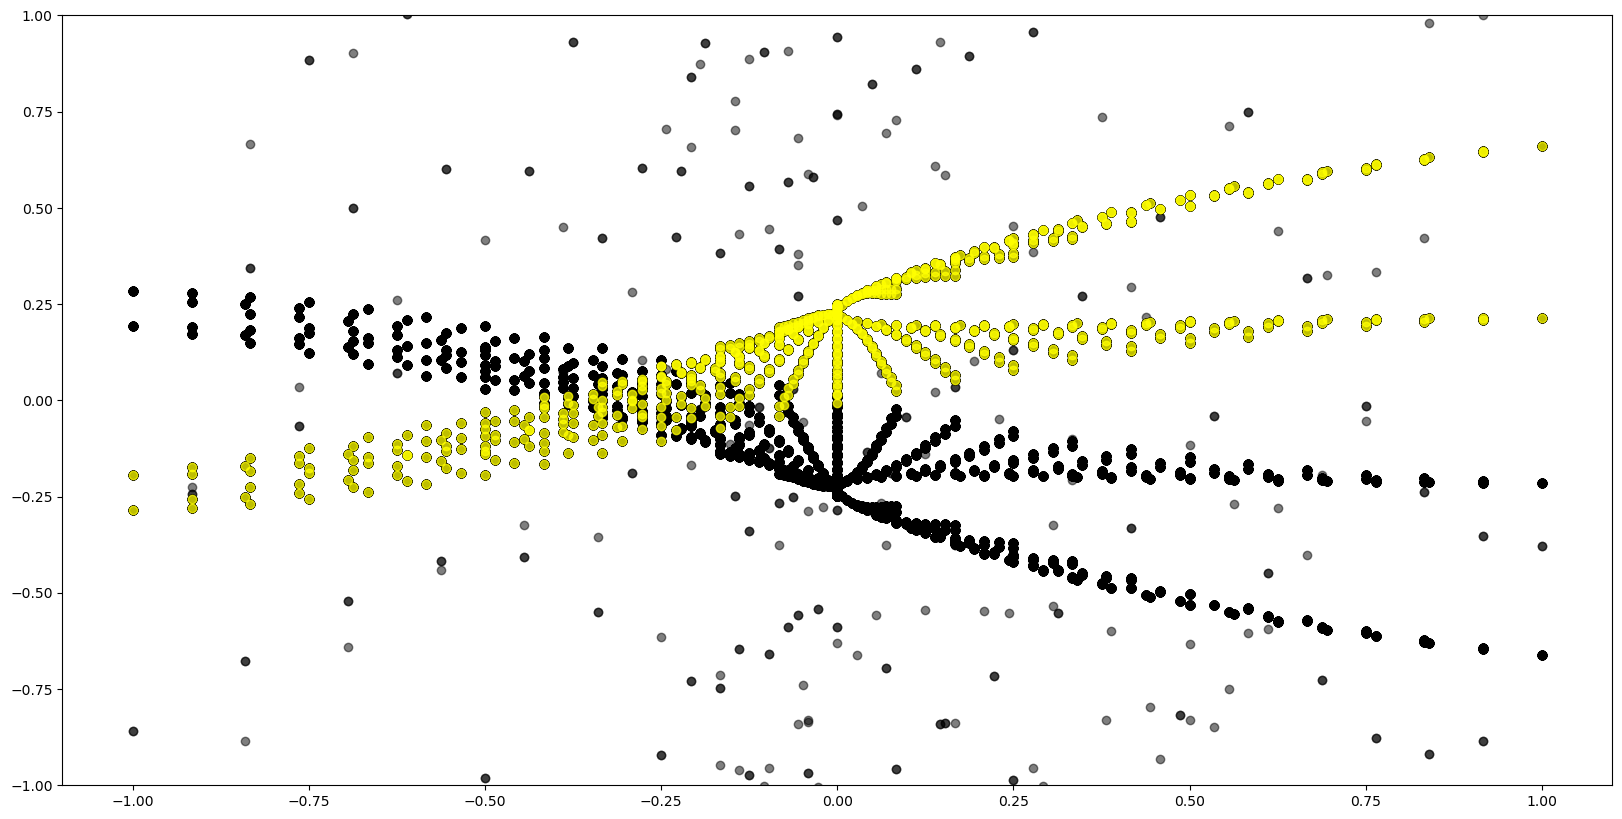

In [32]:
from matplotlib.cm import ScalarMappable

max_iter = 200
tol = 1e-10
damping = 0.7 

def make_correlated_samples(L, n_power=6):
    dim = L.shape[1]
    x = torch.normal(mean=0, std=1, size=(dim, 2**n_power))
    z = L@x        
    return z

_sigma_m, _sigma_n, _sigma_I, _rho_mn, _h_0 = sigma_m.detach()[order], sigma_n.detach()[order], sigma_I.detach()[order], rho_mn.detach()[order], h_0.detach()[order]

cov = torch.stack([
    torch.stack([_sigma_m**2, _sigma_m * _sigma_n * _rho_mn, torch.zeros_like(_sigma_m), torch.zeros_like(_sigma_m)], dim=1),
    torch.stack([_sigma_m * _sigma_n * _rho_mn, _sigma_n**2, torch.zeros_like(_sigma_n), torch.zeros_like(_sigma_n)], dim=1),
    torch.stack([torch.zeros_like(_sigma_I), torch.zeros_like(_sigma_I), _sigma_I**2, torch.zeros_like(_sigma_I)], dim=1),
    torch.stack([torch.zeros_like(_sigma_I), torch.zeros_like(_sigma_I), torch.zeros_like(_sigma_I), _sigma_I**2], dim=1)
], dim=1)

L, info = torch.linalg.cholesky_ex(cov)

# info == 0 means success
valid = (info == 0)
print(f'usable optimisations: {valid.sum().item()}')

# keep only successful decompositions
L = L[valid]          # shape [B', 4, 4]
cov = cov[valid]      # optional, same B'
_sigma_m, _sigma_n, _sigma_I, _rho_mn, _h_0 = _sigma_m[valid], _sigma_n[valid], _sigma_I[valid], _rho_mn[valid], _h_0[valid]

z = make_correlated_samples(L, n_power=6).transpose(1, 0)

m  = z[0]           # (valid, samples)
n_perp  = z[1]      
I_A = z[2]   
I_B = z[3]   
n = n_perp + (1/_sigma_I**2)[:,None]*I_A*I_B
c = 1


with torch.no_grad():
    K = torch.zeros((aa.shape[0], m.shape[0]))     # (n_inputs, valid)
    for _ in range(max_iter):

        h = torch.einsum('vs,sn->vsn', K, m) + torch.einsum('v,sn->vsn', aa, I_A) + torch.einsum('v,sn->vsn', bb, I_B) + c

        K_new = torch.einsum('sn,vsn->vsn', n, phi(h)).mean(dim=2)

        err = torch.max(torch.abs(K_new - K))
        K = damping * K_new + (1.0 - damping) * K

        if err < tol:
            break
 

_w = (1 - _sigma_m * _sigma_n * _rho_mn * (d1phi(_h_0) - d2phi(_h_0)*_h_0)) / (_sigma_I**2 * d2phi(_h_0))
print(_w.shape, K.shape)

est_ab = torch.einsum('s, vs -> sv', _w, K)                                          # (valid, n_inputs)

error = torch.abs( est_ab - (aa*bb)[None,:] ).mean(axis=1)                           # (valid)

best_params = np.argmin( error )

fig, ax = plt.subplots(1, 1, figsize=(20,10))

# ax[0].plot(h_0, w)
# ax[0].set_yscale('log')

# cmap = colormaps.get_cmap('RdBu')
# norm = Normalize(vmin=h_0[0], vmax=h_0[-1])
for i in range(len(_w)):
    ax.scatter(aa*bb, est_ab[i], alpha=0.5, color='k')
ax.scatter(aa*bb, est_ab[best_params], color='yellow', alpha=0.75)
ax.set_ylim((aa*bb).min(), (aa*bb).max())

# sm = ScalarMappable(norm=norm, cmap=cmap)
# fig.colorbar(sm, ax=ax[1], orientation='horizontal')
# ax[1].set_ylim(((aa*bb).min(), (aa*bb).max()))
# ax[1].plot(np.linspace((aa*bb).min(), (aa*bb).max(), 100), np.linspace((aa*bb).min(), (aa*bb).max(), 100), ls='--', color='k')

# ax[2].plot(h_0, error)
# ax[2].scatter(h_0[ best_h_0 ], error[ best_h_0 ], color='yellow', s=50)
# ax[2].set_yscale('log')


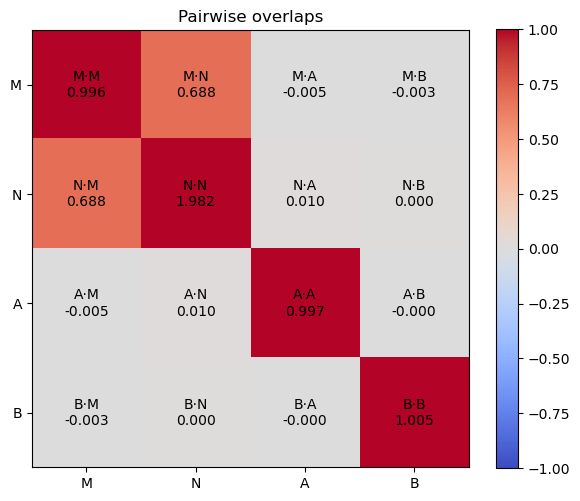

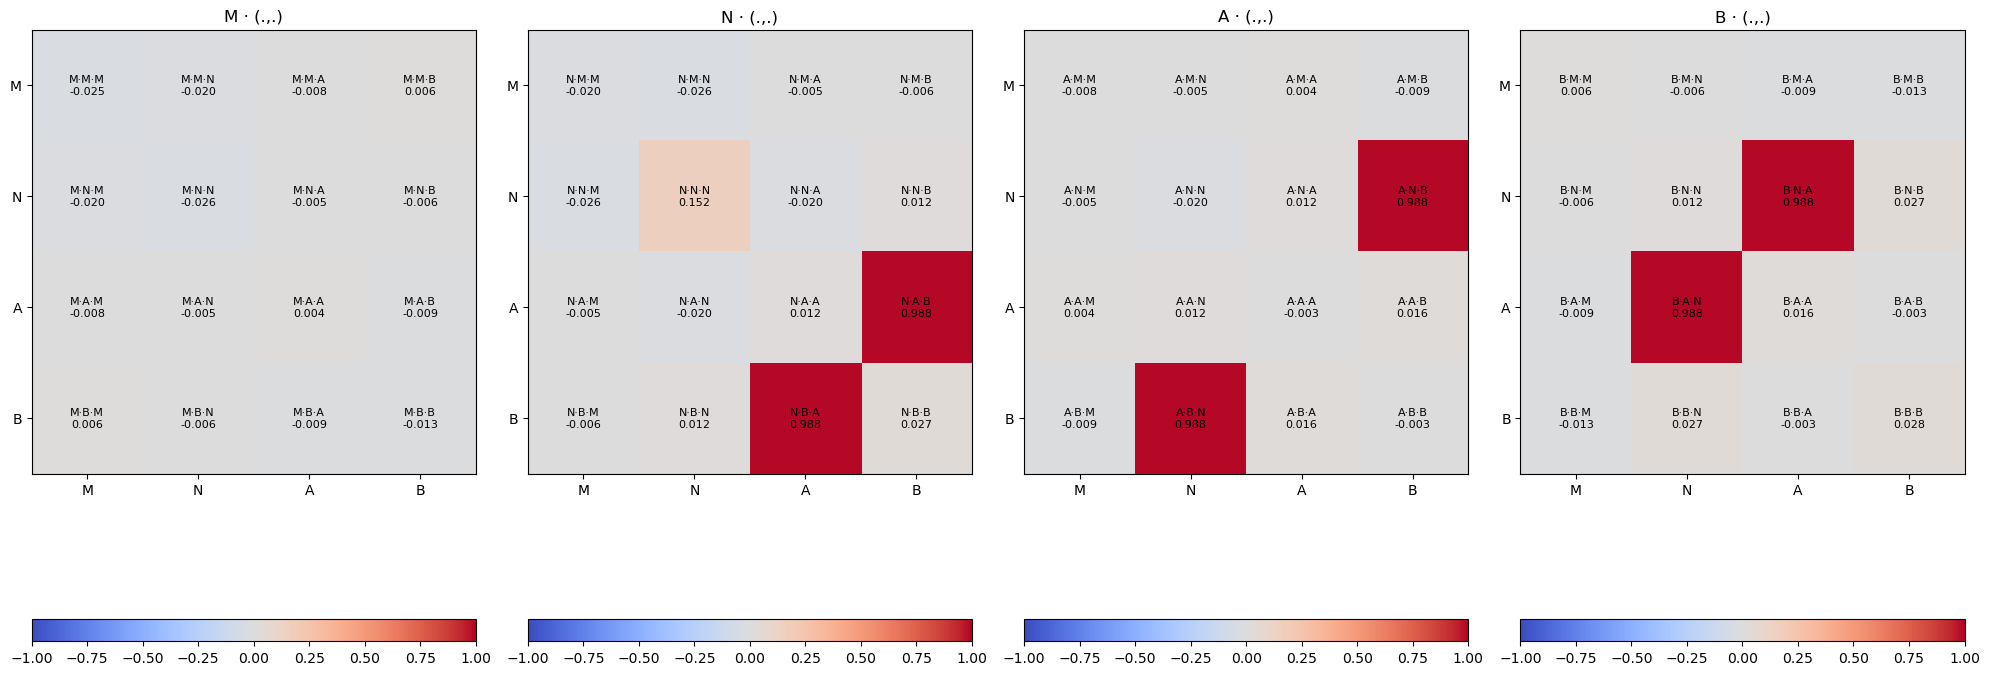

In [90]:
Y = np.stack([m, n, I_A, I_B], axis=0)   # shape: (4, S, N)

# Pairwise overlaps: shape (4, 4)
Q = np.einsum('asn, bsn -> ab', Y, Y) / (Y.shape[1] * Y.shape[2])

# Ternary overlaps: shape (4, 4, 4)
T = np.einsum('asn, bsn, csn -> abc', Y, Y, Y) / (Y.shape[1] * Y.shape[2])

names = ["M","N","A","B"]
num = len(names)

cmap = colormaps.get_cmap('coolwarm')
from matplotlib.colors import Normalize
norm = Normalize(vmin=-1, vmax=1)

# -------- Pairwise overlaps --------

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(Q, cmap=cmap, norm=norm)

ax.set_xticks(range(num))
ax.set_yticks(range(num))
ax.set_xticklabels(names)
ax.set_yticklabels(names)

ax.set_title("Pairwise overlaps")

for i in range(num):
    for j in range(num):
        ax.text(j, i, f"{names[i]}·{names[j]}\n{Q[i,j]:.3f}",
                ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()


# -------- Ternary overlaps --------

fig, axes = plt.subplots(1, num, figsize=(20,10))

for a, ax in enumerate(axes):

    im = ax.imshow(T[a], cmap=cmap, norm=norm)

    fig.colorbar(im, ax=ax, orientation='horizontal')

    ax.set_xticks(range(num))
    ax.set_yticks(range(num))
    ax.set_xticklabels(names)
    ax.set_yticklabels(names)

    ax.set_title(f"{names[a]} · (.,.)")

    for b in range(num):
        for c in range(num):
            ax.text(c, b,
                    f"{names[a]}·{names[b]}·{names[c]}\n{T[a,b,c]:.3f}",
                    ha="center", va="center", fontsize=8)

plt.tight_layout()

plt.show()

/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_1104/2617597198.py:180: RuntimeWarning: overflow encountered in multiply
  kpow = kpow * kappa
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_1104/2617597198.py:181: RuntimeWarning: invalid value encountered in add
  out += terms_by_p[p] * kpow
/var/folders/3v/s6m527mn1_dc3cs0ck12y0jw0000gn/T/ipykernel_1104/2617597198.py:200: RuntimeWarning: invalid value encountered in subtract
  err = np.max(np.abs(new - kappa))



Taylor approximation metrics
------------------------------------------------------------------------
   order           RMSE            MAE            R^2           corr
------------------------------------------------------------------------
       1   1.085294e-02   7.560641e-03   6.229744e-01   9.783005e-01
       2   1.085294e-02   7.560641e-03   6.229744e-01   9.783005e-01
       3   3.774071e-03   2.303001e-03   9.544072e-01   9.821237e-01
       4   3.774071e-03   2.303001e-03   9.544072e-01   9.821237e-01
       5   6.861707e-03   2.942119e-03   8.492907e-01   9.533919e-01
       6   6.861707e-03   2.942119e-03   8.492907e-01   9.533919e-01
       7   7.866403e-03   2.861050e-03   8.019257e-01   9.001142e-01
       8   7.866403e-03   2.861050e-03   8.019257e-01   9.001142e-01
       9            nan            nan            nan            nan


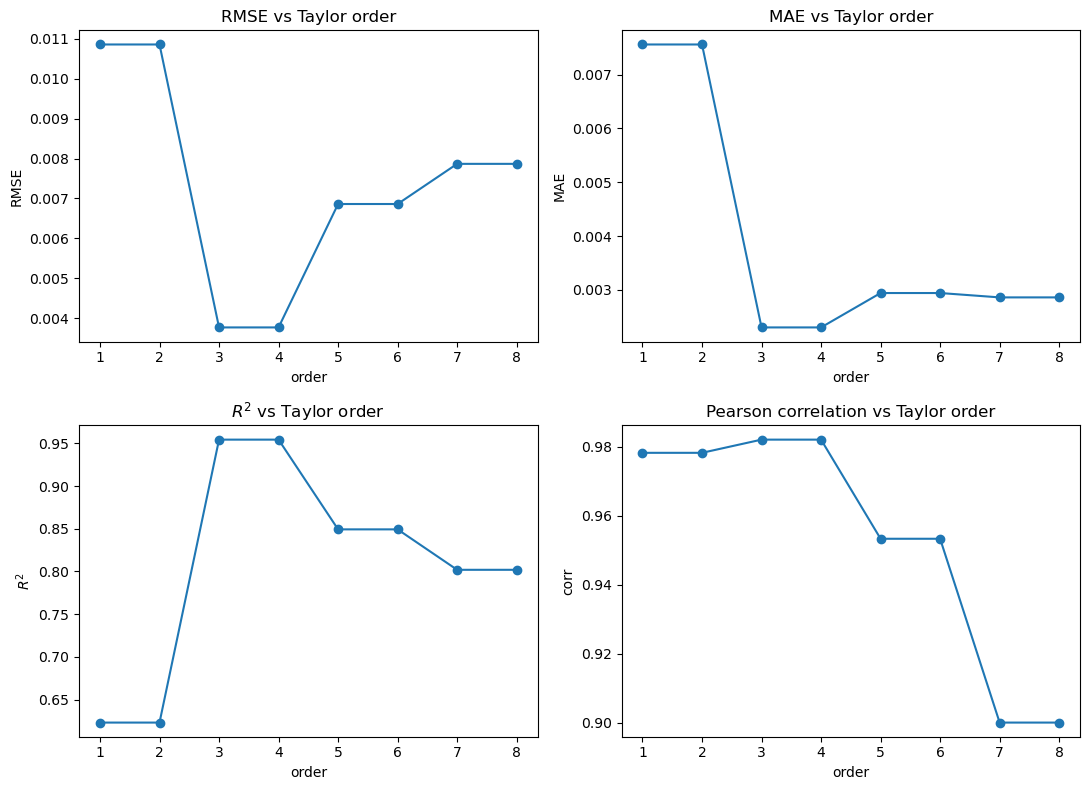

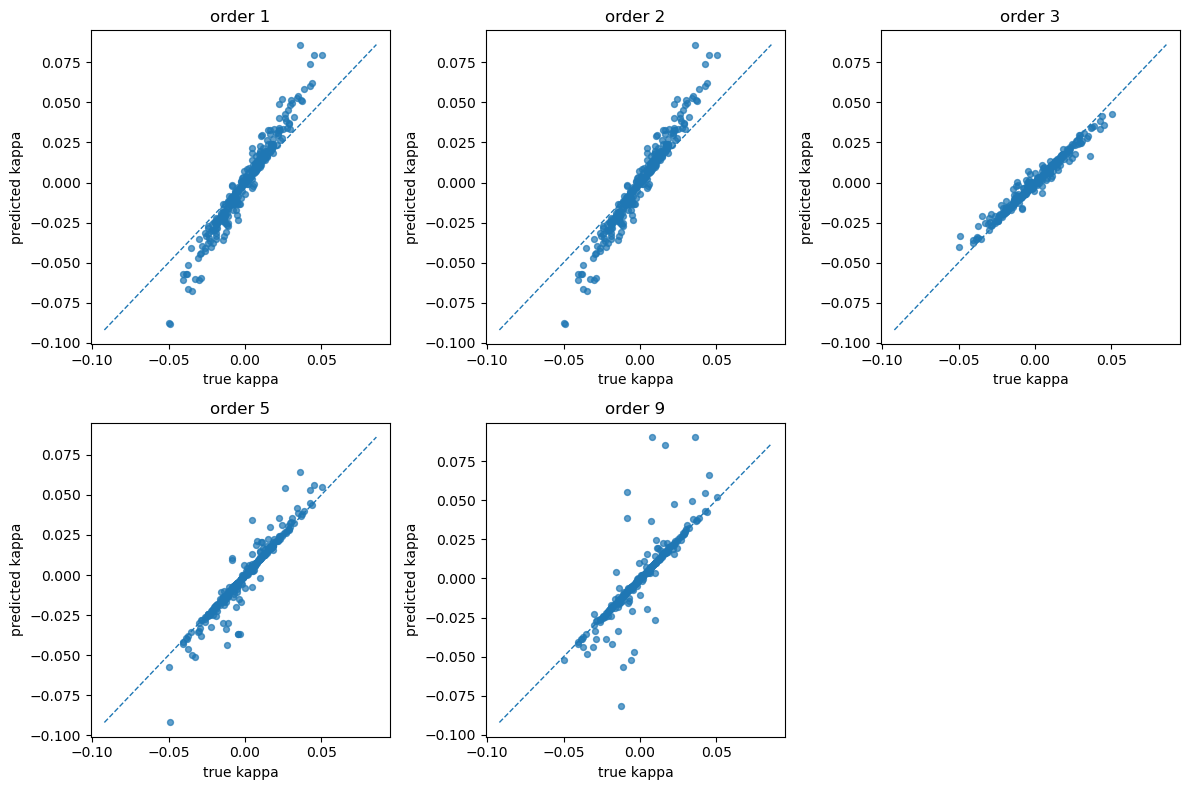

In [155]:
import math
import itertools
from typing import Callable, Dict, Tuple, List

import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp


# ============================================================
# User-facing configuration
# ============================================================

# Example nonlinearity. Replace with your own if needed.
# Note: for phi = tanh expanded about 0, even orders vanish,
# so pure ab terms will not appear at quadratic order unless
# you instead expand about a biased operating point x0 != 0.
phi_scalar = lambda x: mp.tanh( x )

# Taylor expansion point.
x0 = 0.0

# Maximum Taylor order to test
max_order = 9

# Fixed-point iteration settings for the truncated map
max_iter = 500
tol = 1e-12
damping = 0.5  # in (0, 1]; smaller can help stability

# If K has shape (S, N), reduce it to one scalar kappa per sample.
# If your K is already shape (S,), this is ignored.
target_reduce = np.mean


# ============================================================
# Helper functions
# ============================================================

def multinomial3(p: int, q: int, r: int) -> int:
    """Return (p+q+r)! / (p! q! r!)."""
    n = p + q + r
    return math.factorial(n) // (
        math.factorial(p) * math.factorial(q) * math.factorial(r)
    )


def taylor_coefficients(phi: Callable[[float], float],
                        max_order: int,
                        x0: float = 0.0) -> np.ndarray:
    """
    Compute Taylor coefficients c_l = phi^(l)(x0) / l! for l = 0..max_order.

    Uses mpmath differentiation, so `phi` should be an mpmath-compatible scalar function.
    """
    coeffs = np.zeros(max_order + 1, dtype=np.float64)
    for l in range(max_order + 1):
        deriv = mp.diff(phi, x0, l)
        coeffs[l] = float(deriv / math.factorial(l))
    return coeffs


def reduce_target_kappa(K: np.ndarray,
                        reducer: Callable[[np.ndarray], float] = np.mean) -> np.ndarray:
    """
    Convert K to shape (S,). If K is already 1D, return it.
    If K is 2D, reduce over axis 1.

    Assumption:
        K[s, :] contains per-unit contributions whose average is the sample's scalar kappa.
    """
    K = np.asarray(K)
    if K.ndim == 1:
        return K.astype(np.float64)
    if K.ndim == 2:
        return reducer(K, axis=1).astype(np.float64)
    raise ValueError(f"K must have ndim 1 or 2, got shape {K.shape}")


def empirical_overlaps(
    M: np.ndarray,
    Nvec: np.ndarray,
    IA: np.ndarray,
    IB: np.ndarray,
    max_order: int,
) -> Dict[Tuple[int, int, int], np.ndarray]:
    """
    Compute overlaps for all tuples (p, q, r) with p+q+r <= max_order:
        O_{pqr}[s] = mean_i N[s,i] * M[s,i]^p * IA[s,i]^q * IB[s,i]^r

    Returns
    -------
    overlaps : dict mapping (p,q,r) -> ndarray of shape (S,)
    """
    M = np.asarray(M, dtype=np.float64)
    Nvec = np.asarray(Nvec, dtype=np.float64)
    IA = np.asarray(IA, dtype=np.float64)
    IB = np.asarray(IB, dtype=np.float64)

    if not (M.shape == Nvec.shape == IA.shape == IB.shape):
        raise ValueError("M, Nvec, IA, IB must all have the same shape (S, N)")

    S, N = M.shape
    overlaps = {}

    # Precompute powers samplewise for efficiency
    M_powers = [np.ones_like(M)]
    IA_powers = [np.ones_like(IA)]
    IB_powers = [np.ones_like(IB)]

    for k in range(1, max_order + 1):
        M_powers.append(M_powers[-1] * M)
        IA_powers.append(IA_powers[-1] * IA)
        IB_powers.append(IB_powers[-1] * IB)

    for total in range(max_order + 1):
        for p in range(total + 1):
            for q in range(total - p + 1):
                r = total - p - q
                arr = Nvec * M_powers[p] * IA_powers[q] * IB_powers[r]
                overlaps[(p, q, r)] = arr.mean(axis=1)

    return overlaps


def truncated_map_factory(
    coeffs: np.ndarray,
    overlaps: Dict[Tuple[int, int, int], np.ndarray],
    A: np.ndarray,
    B: np.ndarray,
    order: int,
):
    """
    Build the order-n truncated map F_n such that kappa = F_n(kappa; a,b).
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    S = A.shape[0]

    if B.shape[0] != S:
        raise ValueError("A and B must have shape (S,)")

    # Precompute scalar prefactors for each sample and monomial
    # term for fixed l,p,q,r:
    # c_l * multinomial(p,q,r) * overlap_{pqr}[s] * a[s]^q * b[s]^r
    terms_by_p: Dict[int, np.ndarray] = {}

    for p in range(order + 1):
        terms_by_p[p] = np.zeros(S, dtype=np.float64)

    for l in range(order + 1):
        c_l = coeffs[l]
        if c_l == 0.0:
            continue
        for p in range(l + 1):
            for q in range(l - p + 1):
                r = l - p - q
                pref = (
                    c_l
                    * multinomial3(p, q, r)
                    * overlaps[(p, q, r)]
                    * (A ** q)
                    * (B ** r)
                )
                terms_by_p[p] += pref

    def F(kappa: np.ndarray) -> np.ndarray:
        """
        Vectorized evaluation over samples:
            F_s(kappa_s) = sum_p terms_by_p[p][s] * (kappa_s - x0)^p
        because phi is expanded around x0. If you want an exact shift:
            phi(z) ~ sum_l c_l (z - x0)^l
        Here z = m*kappa + IA*a + IB*b, and we are not separately shifting z.
        So for now x0 should usually be 0.
        """
        out = np.zeros_like(kappa, dtype=np.float64)
        kpow = np.ones_like(kappa, dtype=np.float64)
        for p in range(order + 1):
            if p > 0:
                kpow = kpow * kappa
            out += terms_by_p[p] * kpow
        return out

    return F


def solve_truncated_fixed_point(
    F: Callable[[np.ndarray], np.ndarray],
    init: np.ndarray,
    max_iter: int = 500,
    tol: float = 1e-12,
    damping: float = 1.0,
) -> np.ndarray:
    """
    Solve kappa = F(kappa) by damped fixed-point iteration, vectorized over samples.
    """
    kappa = init.astype(np.float64).copy()
    for _ in range(max_iter):
        new = (1.0 - damping) * kappa + damping * F(kappa)
        err = np.max(np.abs(new - kappa))
        kappa = new
        if err < tol:
            break
    return kappa


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """
    Compute RMSE, MAE, R^2, Pearson correlation.
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    resid = y_pred - y_true
    rmse = np.sqrt(np.mean(resid ** 2))
    mae = np.mean(np.abs(resid))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    yt = y_true - y_true.mean()
    yp = y_pred - y_pred.mean()
    denom = np.sqrt(np.sum(yt ** 2) * np.sum(yp ** 2))
    corr = np.sum(yt * yp) / denom if denom > 0 else np.nan

    return {"rmse": rmse, "mae": mae, "r2": r2, "corr": corr}


def evaluate_orders(
    K: np.ndarray,
    M: np.ndarray,
    Nvec: np.ndarray,
    IA: np.ndarray,
    IB: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    phi_scalar: Callable[[float], float],
    max_order: int = 7,
    x0: float = 0.0,
    target_reduce: Callable[[np.ndarray], float] = np.mean,
    max_iter: int = 500,
    tol: float = 1e-12,
    damping: float = 0.5,
):
    """
    Main driver.
    """
    # Target scalar kappas
    kappa_true = reduce_target_kappa(K, reducer=target_reduce)

    # Taylor coefficients
    coeffs = taylor_coefficients(phi_scalar, max_order=max_order, x0=x0)

    # Empirical overlaps
    overlaps = empirical_overlaps(M, Nvec, IA, IB, max_order=max_order)

    # Evaluate approximations as order increases
    orders = list(range(1, max_order + 1))
    preds = {}
    metrics = []

    # Start from zero and warm-start each higher order with previous solution
    kappa_init = np.zeros_like(kappa_true)

    for order in orders:
        F_n = truncated_map_factory(coeffs, overlaps, A, B, order=order)
        kappa_pred = solve_truncated_fixed_point(
            F_n,
            init=kappa_init,
            max_iter=max_iter,
            tol=tol,
            damping=damping,
        )
        preds[order] = kappa_pred
        metrics.append({"order": order, **regression_metrics(kappa_true, kappa_pred)})
        kappa_init = kappa_pred

    return kappa_true, preds, metrics, coeffs, overlaps


def plot_accuracy(metrics: List[Dict[str, float]]) -> None:
    orders = [m["order"] for m in metrics]
    rmse = [m["rmse"] for m in metrics]
    mae = [m["mae"] for m in metrics]
    r2 = [m["r2"] for m in metrics]
    corr = [m["corr"] for m in metrics]

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    axes[0, 0].plot(orders, rmse, marker="o")
    axes[0, 0].set_title("RMSE vs Taylor order")
    axes[0, 0].set_xlabel("order")
    axes[0, 0].set_ylabel("RMSE")

    axes[0, 1].plot(orders, mae, marker="o")
    axes[0, 1].set_title("MAE vs Taylor order")
    axes[0, 1].set_xlabel("order")
    axes[0, 1].set_ylabel("MAE")

    axes[1, 0].plot(orders, r2, marker="o")
    axes[1, 0].set_title(r"$R^2$ vs Taylor order")
    axes[1, 0].set_xlabel("order")
    axes[1, 0].set_ylabel(r"$R^2$")

    axes[1, 1].plot(orders, corr, marker="o")
    axes[1, 1].set_title("Pearson correlation vs Taylor order")
    axes[1, 1].set_xlabel("order")
    axes[1, 1].set_ylabel("corr")

    fig.tight_layout()
    plt.show()


def plot_scatter_grid(kappa_true: np.ndarray,
                      preds: Dict[int, np.ndarray],
                      orders_to_show: List[int]) -> None:
    """
    Scatter plots of predicted vs true kappas for selected orders.
    """
    n_show = len(orders_to_show)
    ncols = min(3, n_show)
    nrows = int(np.ceil(n_show / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    lo = min(kappa_true.min(), *(preds[o].min() for o in orders_to_show))
    hi = max(kappa_true.max(), *(preds[o].max() for o in orders_to_show))

    for ax, order in zip(axes, orders_to_show):
        kp = preds[order]
        ax.scatter(kappa_true, kp, s=18, alpha=0.7)
        ax.plot([lo, hi], [lo, hi], "--", linewidth=1)
        ax.set_title(f"order {order}")
        ax.set_xlabel("true kappa")
        ax.set_ylabel("predicted kappa")

    for ax in axes[n_show:]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # Replace this block with your real data loading
    # --------------------------------------------------------
    rng = np.random.default_rng(1)

    S = 300   # number of samples
    N = 2000  # units per sample

    # Example synthetic data
    M = rng.normal(size=(S, N))
    Nvec = 0.7 * M + np.sqrt(1 - 0.7**2) * rng.normal(size=(S, N))
    IA = rng.normal(size=(S, N))
    IB = rng.normal(size=(S, N))
    A = rng.uniform(-0.5, 0.5, size=S)
    B = rng.uniform(-0.5, 0.5, size=S)

    # Build a "ground truth" scalar kappa by solving the full nonlinear equation
    # and then store it in K with shape (S, N) just to match your stated format.
    kappa_true_scalar = np.zeros(S, dtype=np.float64)
    for _ in range(300):
        h = M * kappa_true_scalar[:, None] + IA * A[:, None] + IB * B[:, None]
        new = np.mean(Nvec * np.tanh(h), axis=1)
        kappa_true_scalar = 0.5 * kappa_true_scalar + 0.5 * new

    # Here I construct K as repeated scalar kappas per unit,
    # so reduce_target_kappa(K) recovers kappa_true_scalar.
    K = np.repeat(kappa_true_scalar[:, None], N, axis=1)

    # --------------------------------------------------------
    # Run evaluation
    # --------------------------------------------------------
    kappa_true, preds, metrics, coeffs, overlaps = evaluate_orders(
        K=K,
        M=M,
        Nvec=Nvec,
        IA=IA,
        IB=IB,
        A=A,
        B=B,
        phi_scalar=phi_scalar,
        max_order=max_order,
        x0=x0,
        target_reduce=target_reduce,
        max_iter=max_iter,
        tol=tol,
        damping=damping,
    )

    # Print summary table
    print("\nTaylor approximation metrics")
    print("-" * 72)
    print(f"{'order':>8} {'RMSE':>14} {'MAE':>14} {'R^2':>14} {'corr':>14}")
    print("-" * 72)
    for m in metrics:
        print(
            f"{m['order']:8d} "
            f"{m['rmse']:14.6e} "
            f"{m['mae']:14.6e} "
            f"{m['r2']:14.6e} "
            f"{m['corr']:14.6e}"
        )

    # Plot accuracy as order increases
    plot_accuracy(metrics)

    # Scatter plots for a few selected orders
    orders_to_show = sorted(set([1, 2, 3, 5, max_order]))
    plot_scatter_grid(kappa_true, preds, orders_to_show)